In [1]:
import pandas as pd
import pyunicorn as pyy
import matplotlib.pyplot as plt
import time
from scipy.spatial import KDTree
import statistics as stat
from pyunicorn.timeseries import RecurrencePlot
import numpy as np
from statsmodels.tsa.stattools import acf
import pymannkendall as mk
import nolds
import warnings
warnings.filterwarnings("ignore", message="RANSAC did not reach consensus, using numpy's polyfit")
start=time.time()

C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\nolds\datasets.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
# def ews(jd_final,mag_final,window,name):
#     nvals = np.unique(np.round(np.logspace(np.log10(5), np.log10(window/4), num=10)).astype(int))
#     # sliding windows 
#     jdfw=[]
#     jdavg=[]
#     magfw=[]
#     lamm=[]
#     detm=[]
#     acf_lag1_list=[]
#     variance=[]
#     dfaalpha=[]
#     magfg=[]
#     for i in range (0,(len(jd_final))-window-1):
#         magfw=mag_final[i:i+window]
#         jdfw=jd_final[i:i+window]
#         jdavg.append(jdfw[-1])
#         acf_vals = acf(magfw, nlags=1, fft=False)
#         acf_lag_1 = acf_vals[1]
#         acf_lag1_list.append(acf_lag_1)
#         #variance
#         variance.append(stat.variance(magfw))
#         #DFA
#         dfaalpha.append(nolds.dfa(magfw,fit_trend="poly",nvals=nvals))  
#         # Recurence plots 
#         rp = RecurrencePlot(np.array(magfw), dim=1, tau=1, metric='supremum',recurrence_rate=0.1)
#         # rp.set_threshold_fixed_rr(0.1)
#         det = rp.determinism()
#         lam = rp.laminarity()
#         detm.append(det)
#         lamm.append(lam)
    
#     print( "Test for DFA  :", mk.hamed_rao_modification_test(dfaalpha, alpha=0.05, lag=None))

#     print( "test for ACF(1)  :", mk.hamed_rao_modification_test(acf_lag1_list, alpha=0.05, lag=None))

#     print( "test for Variance :", mk.hamed_rao_modification_test(variance, alpha=0.05, lag=None))

#     print( "test for DET  :", mk.hamed_rao_modification_test(detm, alpha=0.05, lag=None))

#     print( "test for LAM :", mk.hamed_rao_modification_test(lamm, alpha=0.05, lag=None))
#     plt.figure(figsize=(12,7))
#     plt.scatter(jdavg, acf_lag1_list,label=name)
#     plt.title("ACF(1) vs Time")
#     plt.xlabel("Average Julian Date (Time)")
#     plt.ylabel("Autocorrelation at lag 1")
#     plt.legend()
#     plt.show()

#     plt.figure(figsize=(12, 7))
#     plt.scatter(jdavg,variance,label=name )
#     # # plt.xlim(8000,15100)
#     # plt.ylim(0, 0.05)

#     plt.title("Variance vs Time")
#     plt.xlabel("Average Julian Date (Time)")
#     plt.ylabel("Variance")
#     plt.legend()
#     plt.show()

#     # dfanorm = (dfaalpha - np.min(dfaalpha)) / (np.max(dfaalpha) - np.min(dfaalpha))
#     plt.figure(figsize=(12,7))
#     plt.scatter(jdavg,dfaalpha,label=name)
#     # plt.xlim(8000,15100)
#     plt.title("DFA_alpha vs Time")
#     plt.xlabel("Average Julian Date (Time)")
#     plt.ylabel("DFA_ALPHA")
#     plt.legend()
#     plt.show()

#     plt.figure(figsize=(12,7))
#     plt.scatter(jdavg,detm,label=name)
#     plt.title('DET vs JD')
#     plt.xlabel("Average Julian Date(time)")
#     plt.ylabel("DET")
#     plt.legend()
#     plt.show()

#     plt.figure(figsize=(12, 7))
#     plt.scatter(jdavg,lamm,label=name)
#     plt.title('LAM vs JD')
#     plt.xlabel("Average Julian Date(time)")
#     plt.ylabel("LAM")
#     plt.legend()
#     plt.show()
#     print ("last value of JD Average in window :",jdavg[len(jdavg)-1])
#     print ("First value of JD Average in window :",jdavg[0])


In [3]:
def ews(jd_final, mag_final, window, name):

    nvals = np.unique(
        np.round(
            np.logspace(np.log10(5), np.log10(window/4), num=10)
        ).astype(int)
    )

    # Sliding windows
    jdfw = []
    jdavg = []
    magfw = []

    lamm = []
    detm = []
    acf_lag1_list = []
    variance = []
    dfaalpha = []

    for i in range(0, len(jd_final) - window - 1):

        magfw = mag_final[i:i+window]
        jdfw = jd_final[i:i+window]

        jdavg.append(jdfw[-1])

        # ACF(1)
        acf_vals = acf(magfw, nlags=1, fft=False)
        acf_lag1_list.append(acf_vals[1])

        # Variance
        variance.append(stat.variance(magfw))

        # DFA
        dfaalpha.append(
            nolds.dfa(
                magfw,
                fit_trend="poly",
                nvals=nvals
            )
        )

        # Recurrence plot
        rp = RecurrencePlot(
            np.array(magfw),
            dim=1,
            tau=1,
            metric='supremum',
            recurrence_rate=0.1
        )

        detm.append(rp.determinism())
        lamm.append(rp.laminarity())

    # ----------------------------
    # Statistical tests
    # ----------------------------
    print("Test for DFA       :", mk.hamed_rao_modification_test(dfaalpha))
    print("Test for ACF(1)    :", mk.hamed_rao_modification_test(acf_lag1_list))
    print("Test for Variance  :", mk.hamed_rao_modification_test(variance))
    print("Test for DET       :", mk.hamed_rao_modification_test(detm))
    print("Test for LAM       :", mk.hamed_rao_modification_test(lamm))

    # ----------------------------
    # Plot styling function
    # ----------------------------
    def nice_plot(x, y, title, ylabel):

        fig, ax = plt.subplots(figsize=(18, 7))

        ax.scatter(
            x,
            y,
            s=55,
            alpha=0.85
        )

        ax.set_title(title, fontsize=28, pad=18)
        ax.set_xlabel("Julian Date", fontsize=24, labelpad=12)
        ax.set_ylabel(ylabel, fontsize=24, labelpad=12)

        ax.tick_params(axis='both', labelsize=20, width=1.5)

        # Increase 10^6 font
        ax.xaxis.get_offset_text().set_fontsize(18)
        ax.yaxis.get_offset_text().set_fontsize(18)

        ax.grid(True, alpha=0.25)

        plt.tight_layout()
        plt.show()

    # ----------------------------
    # Plots
    # ----------------------------
    nice_plot(jdavg, acf_lag1_list, "ACF(1) vs Time", "ACF(1)")
    nice_plot(jdavg, variance,      "Variance vs Time", "Variance")
    nice_plot(jdavg, dfaalpha,      "DFA α vs Time", "DFA α")
    nice_plot(jdavg, detm,          "DET vs Time", "DET")
    nice_plot(jdavg, lamm,          "LAM vs Time", "LAM")

    print("\nFirst JD :", jdavg[0])
    print("Last JD  :", jdavg[-1])

In [4]:

def bin_by_days(jd_list, mag_list, bin_width=10):
    jd_array = np.array(jd_list)
    mag_array = np.array(mag_list)
    
    min_jd = int(min(jd_array))
    max_jd = int(max(jd_array))

    binned_jd = []
    binned_mag = []

    for start in range(min_jd, max_jd, bin_width):
        end = start + bin_width
        mask = (jd_array >= start) & (jd_array < end)
        if np.any(mask):
            binned_jd.append(np.mean(jd_array[mask]))
            binned_mag.append(np.mean(mag_array[mask]))

    return binned_jd, binned_mag

In [5]:
def gaps(jd, bin_width=10,bined=True):
    
    gap = []
    jd_array = np.array(jd)
    jmin = int(min(jd_array))
    jmax = int(max(jd_array))
    jd_list = []
    count=0
    if bined==True:
        for bin_start in range(jmin, jmax + bin_width, bin_width):
            bin_end = bin_start + bin_width
            bin_center = bin_start + bin_width / 2
            jd_list.append(bin_start)

            found = np.any((jd_array >= bin_start) & (jd_array < bin_end))

            if found:
                gap.append(0)  # present
            else:
                gap.append(1)  # missing
                count+=1
    else:
        for i in range(0,len(jd_array)-2):
            jd_list.append(jd_array[i+1])
            if jd_array[i+1]-jd_array[i]>1:
                gap.append(1)#missing
                count+=1
            else:
                gap.append(0)#present 


    return gap, sum(gap), jd_list ,count # count = total missing

FOR T CrB:

In [6]:
df=pd.read_csv("TCrB.txt")
# print(df)


print(df.columns)
print(df['Band'].unique())

df1 = df[df["Band"] == "V"]  
df2=df[df["Band"]=="Vis."]
# print(df["Band"].unique())
# df = df[df["Band"] == "Vis." ]
mag_clean = []
jd_clean = []
jd=[]
mag=[]

# Extrecting 
jd1= df1["JD"].tolist()
mag1 = df1["Magnitude"].tolist()
jd2 = df2["JD"].tolist()
mag2 = df2["Magnitude"].tolist()

jd_clean1=[]
mag_clean1=[]

jd_clean2=[]
mag_clean2=[]

#converting data types 
for j, m in zip(jd1, mag1):
    try:
        if isinstance(m, str) and m.strip().startswith('<'):
            m = float(m.strip()[1:])  # remove '<'
        else:
            m = float(m)
        jd_clean1.append(float(j))
        mag_clean1.append(m)
    except:
        continue
for j, m in zip(jd2, mag2):
    try:
        if isinstance(m, str) and m.strip().startswith('<'):
            m = float(m.strip()[1:])  # remove '<'
        else:
            m = float(m)
        jd_clean2.append(float(j))
        mag_clean2.append(m)
    except:
        continue
jd_clean=jd_clean1+jd_clean2
mag_clean=mag_clean1+mag_clean2

#correcting time scale 
# jd_clean = [x - 2440000 for x in jd_clean]

# Zip JD and mag together, sort by JD
sorted_pairs = sorted(zip(jd_clean, mag_clean))

# Unzip the sorted pairs back to separate lists
jd_sorted, mag_sorted = zip(*sorted_pairs)

# Convert back to lists if needed
jd_clean = list(jd_sorted)
mag_clean = list(mag_sorted)

C:\Users\hp\AppData\Local\Temp\ipykernel_12772\2044775488.py:1: DtypeWarning: Columns (2,7,8,12,14,15,20,21,22,23) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("TCrB.txt")


Index(['JD', 'Magnitude', 'Uncertainty', 'HQuncertainty', 'Band',
       'Observer Code', 'Comment Code(s)', 'Comp Star 1', 'Comp Star 2',
       'Charts', 'Comments', 'Transfomed', 'Airmass', 'Validation Flag',
       'Cmag', 'Kmag', 'HJD', 'Star Name', 'Observer Affiliation',
       'Measurement Method', 'Grouping Method', 'ADS Reference', 'Digitizer',
       'Credit'],
      dtype='object')
['Vis.' nan 'Yellow-Vis.' 'Green-Vis.' 'Blue-Vis.' 'V' 'TG' 'CV' 'B' 'I'
 'R' 'TR' 'TB' 'CR' 'U' 'SI' 'SR' 'SG' 'J' 'H' 'HA' 'STHBN' 'SU' 'SZ']


In [7]:
# jdf=jd_clean[3000:118000]
# magf=mag_clean[3000:118000]\
# jdf=jd_clean[118000:]
# magf=mag_clean[118000:]
jdf=jd_clean[3000:]
magf=mag_clean[3000:]
# jd_final=jdf[118511:]
# mag_final=magf[118511:]

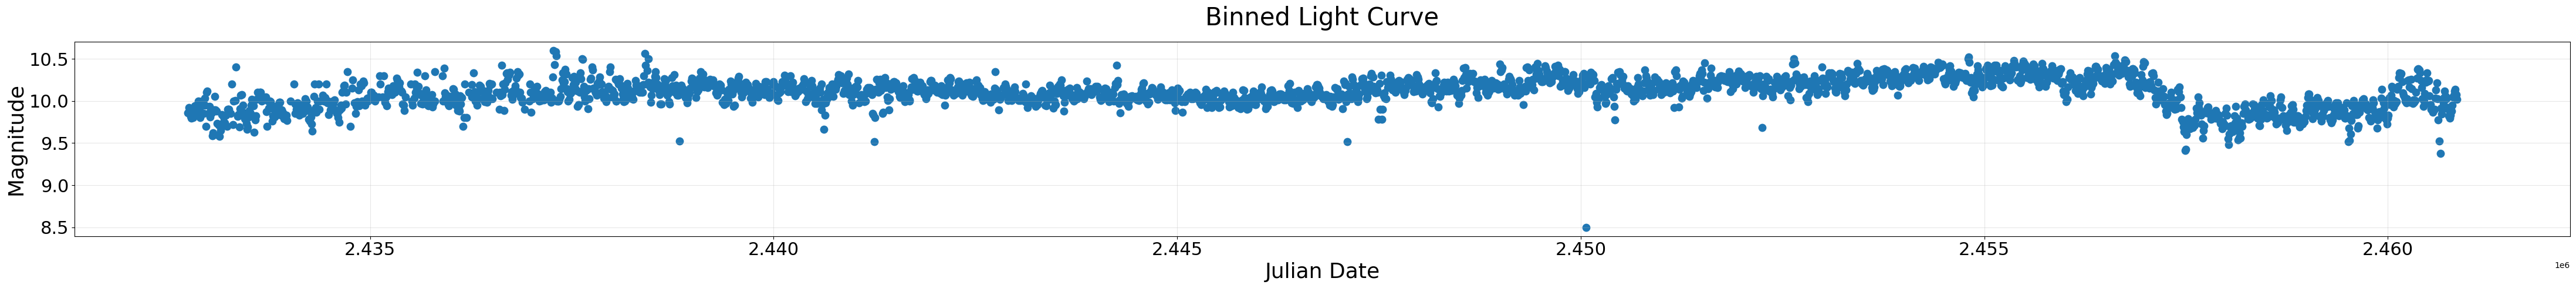

2432743.8927777777 2460852.4437742615


In [8]:
jd_bined = []
mag_bined = []

jd_bined, mag_bined = bin_by_days(jdf, magf)

plt.figure(figsize=(44, 5))

plt.scatter(
    jd_bined,
    mag_bined,
    s=80          # marker size
)

# Axis labels
plt.xlabel("Julian Date", fontsize=26)
plt.ylabel("Magnitude", fontsize=26)

# Title (optional)
plt.title("Binned Light Curve", fontsize=30, pad=20)

# Tick font size
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)

# Grid for readability
plt.grid(alpha=0.3)

# Better spacing
plt.tight_layout()

plt.show()

print(jd_bined[0], jd_bined[-1])

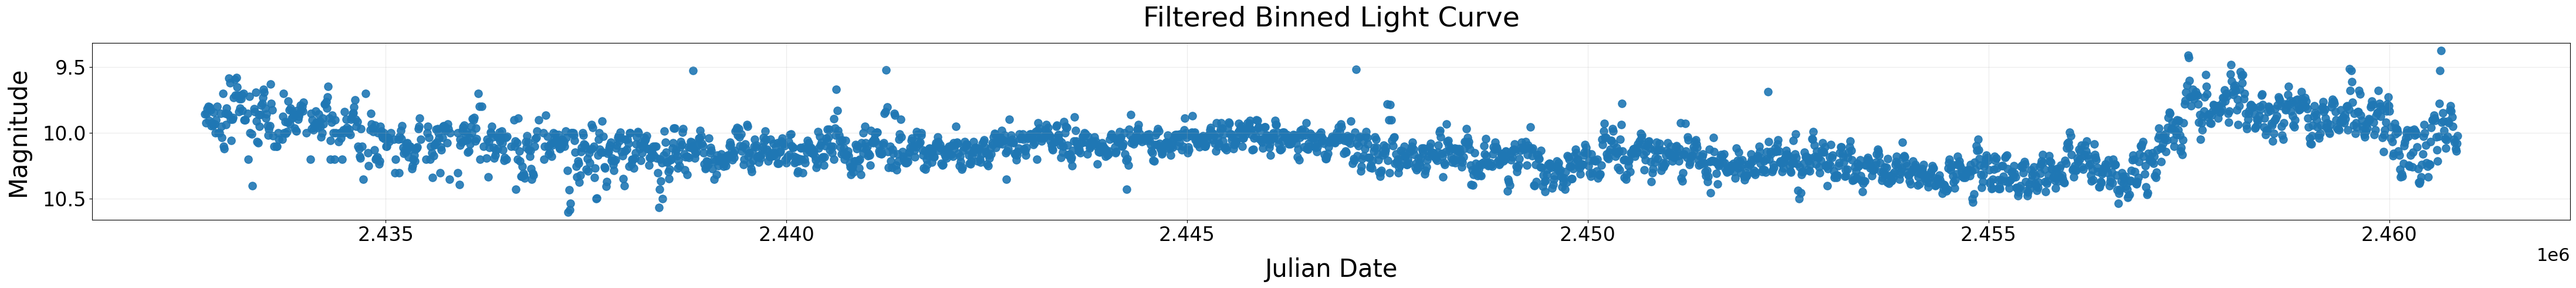

Start JD : 2432743.8927777777
End JD   : 2460852.4437742615


In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Filter data
# ----------------------------
jd_filtered = []
mag_filtered = []

for jd, mag in zip(jd_bined, mag_bined):
    if mag > 9:
        jd_filtered.append(jd)
        mag_filtered.append(mag)

jd_filtered = np.array(jd_filtered)
mag_filtered = np.array(mag_filtered)

# ----------------------------
# Plot
# ----------------------------
fig, ax = plt.subplots(figsize=(44, 5))

ax.scatter(
    jd_filtered,
    mag_filtered,
    s=90,
    alpha=0.9
)

# Labels and title
ax.set_xlabel("Julian Date", fontsize=30, labelpad=15)
ax.set_ylabel("Magnitude", fontsize=30, labelpad=15)
ax.set_title("Filtered Binned Light Curve", fontsize=34, pad=20)

# Tick size
ax.tick_params(axis='both', labelsize=24)

# Increase scientific notation font (10^6)
ax.xaxis.get_offset_text().set_fontsize(22)
ax.yaxis.get_offset_text().set_fontsize(22)

# Astronomy convention (optional but recommended)
ax.invert_yaxis()

# Grid
ax.grid(True, alpha=0.25)

# Layout
plt.tight_layout()
plt.show()

print("Start JD :", jd_filtered[0])
print("End JD   :", jd_filtered[-1])

Detrend 

In [10]:
def detrend(jd_bined,mag_bined,order):
    
    coeffs = np.polyfit(jd_bined, mag_bined, order) 
    trend = np.polyval(coeffs, jd_bined)
    mag_gy= mag_bined - trend
    return mag_gy


In [11]:
flags, missing_count, jd_list ,count= gaps(jd_bined, bin_width=10)
a=jd_bined[-1]-jd_bined[0]
print("Total length of JD:",a)
print("Mising Days:",count*10)
print("percentage of missing days :",((count*10)/a)*100)

Total length of JD: 28108.55099648377
Mising Days: 790
percentage of missing days : 2.8105326386224063


Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...


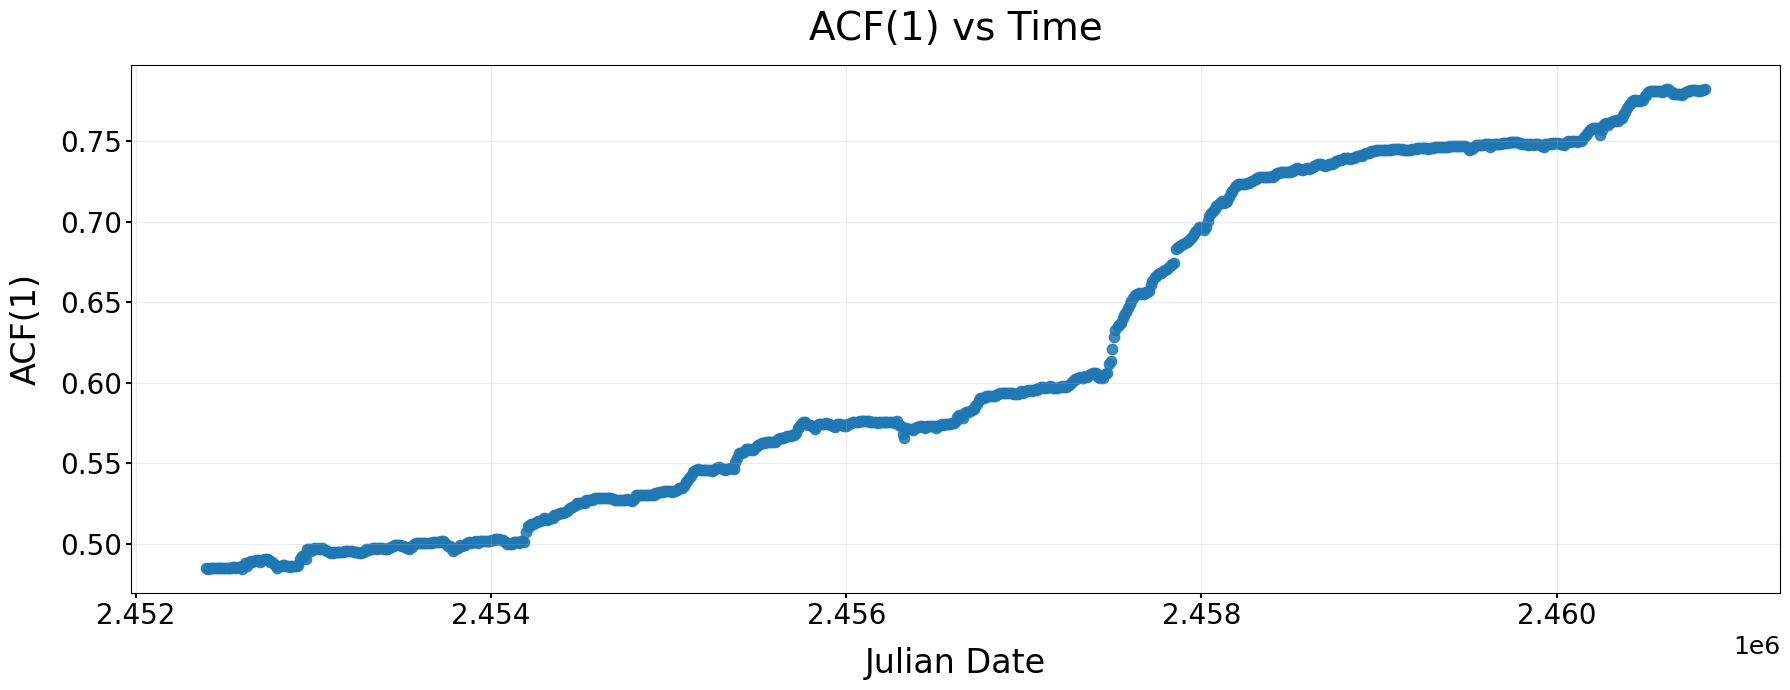

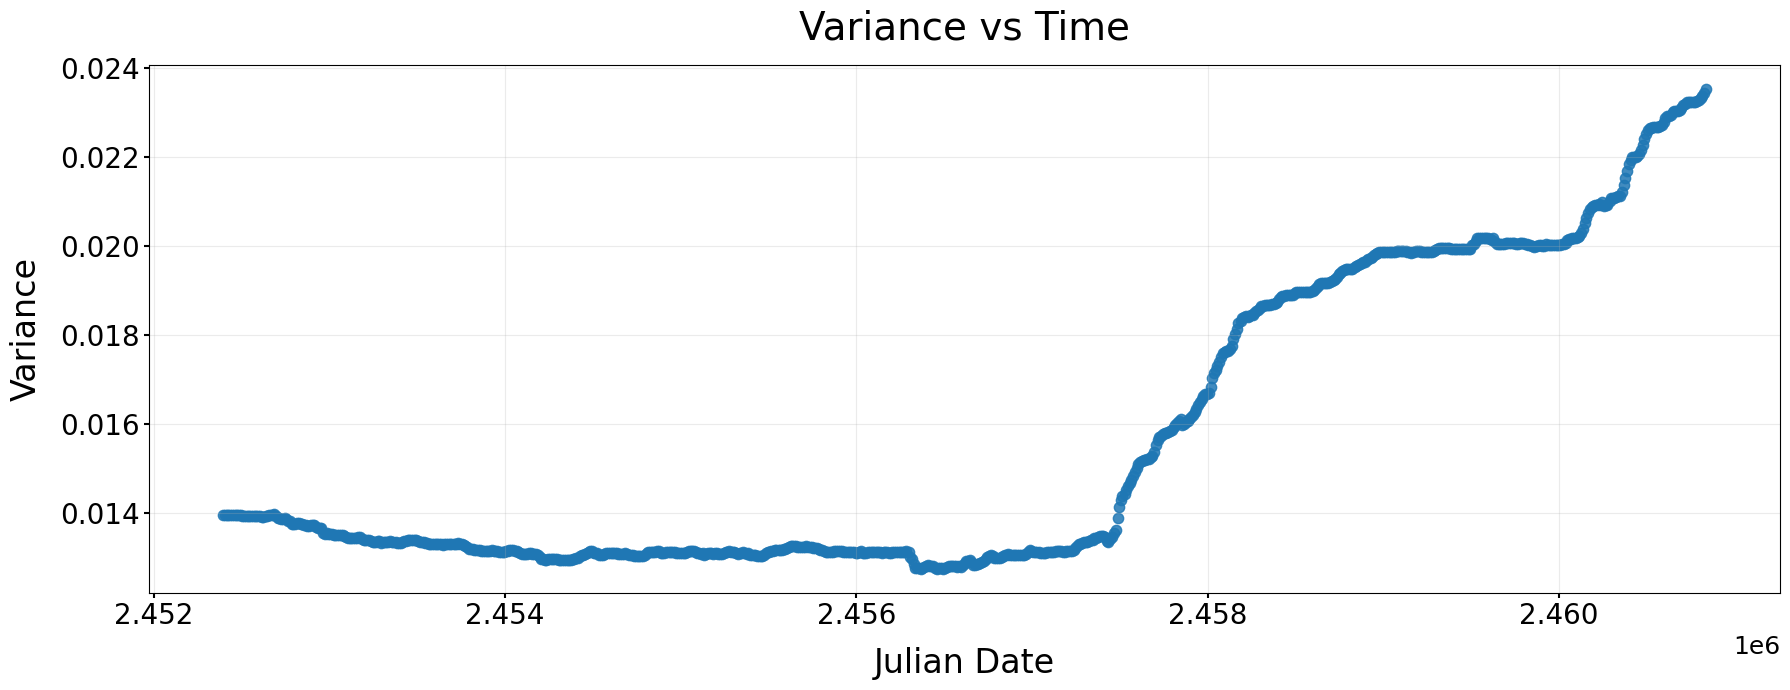

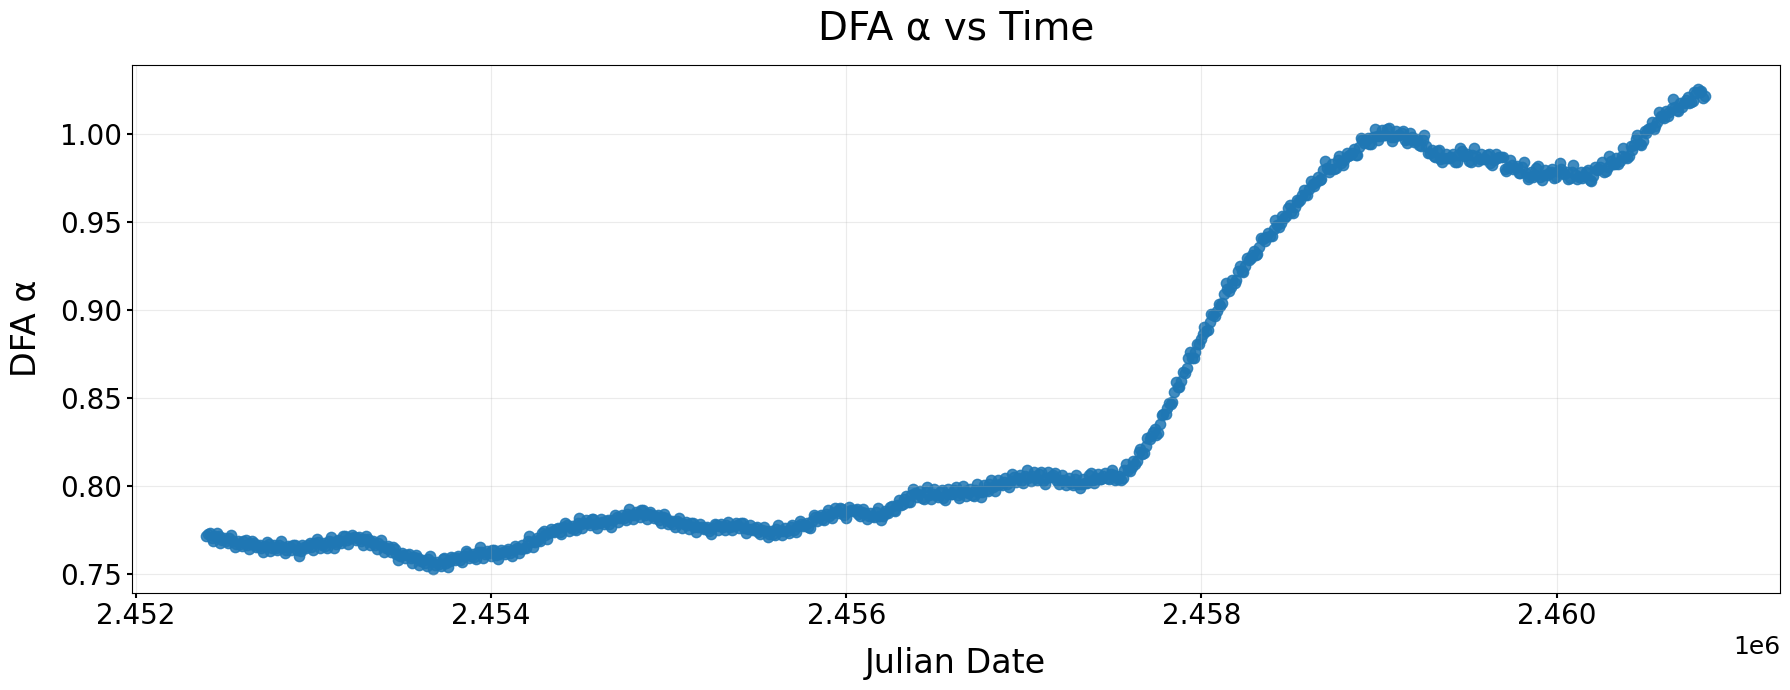

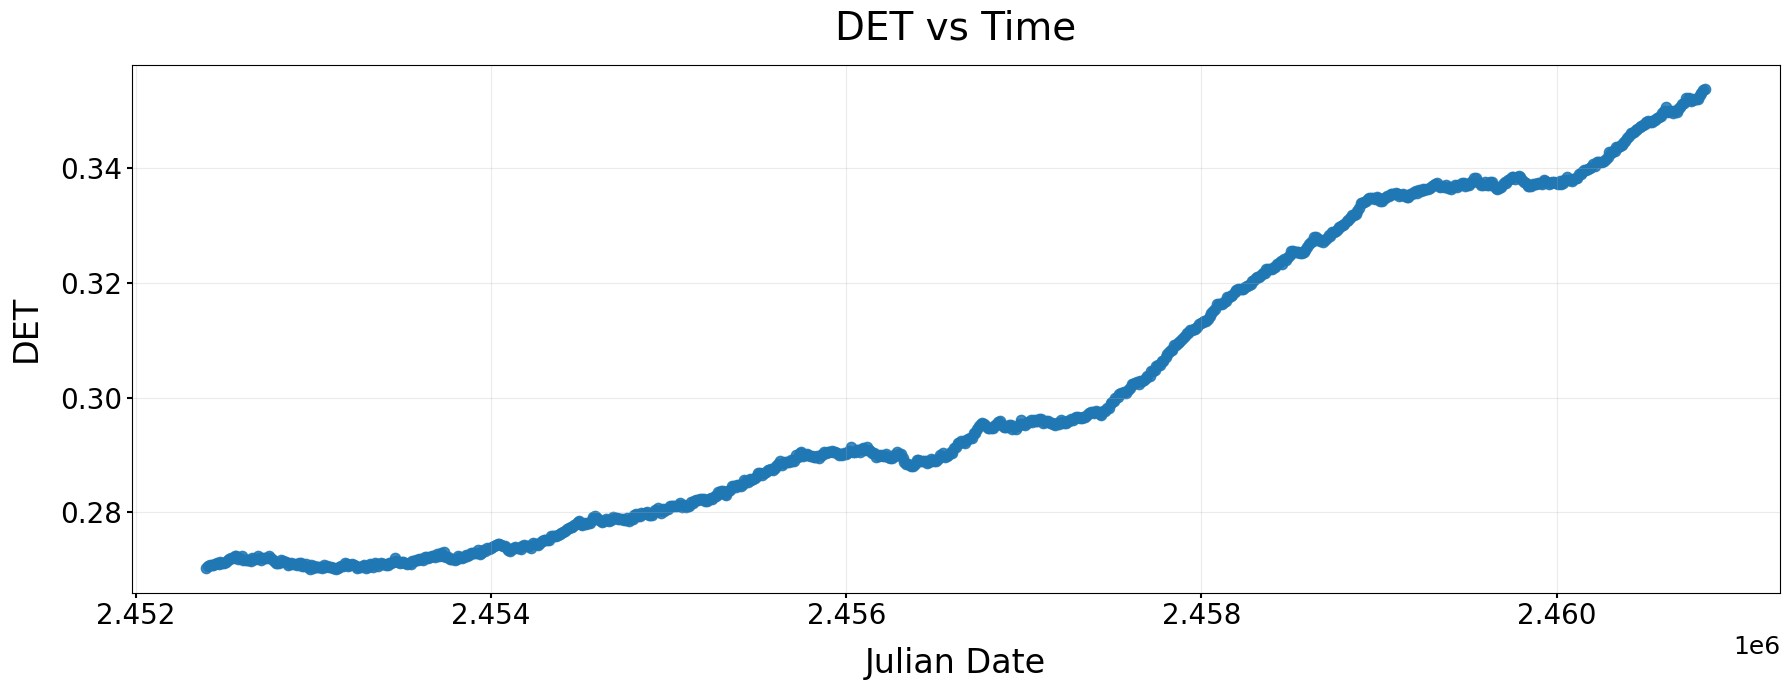

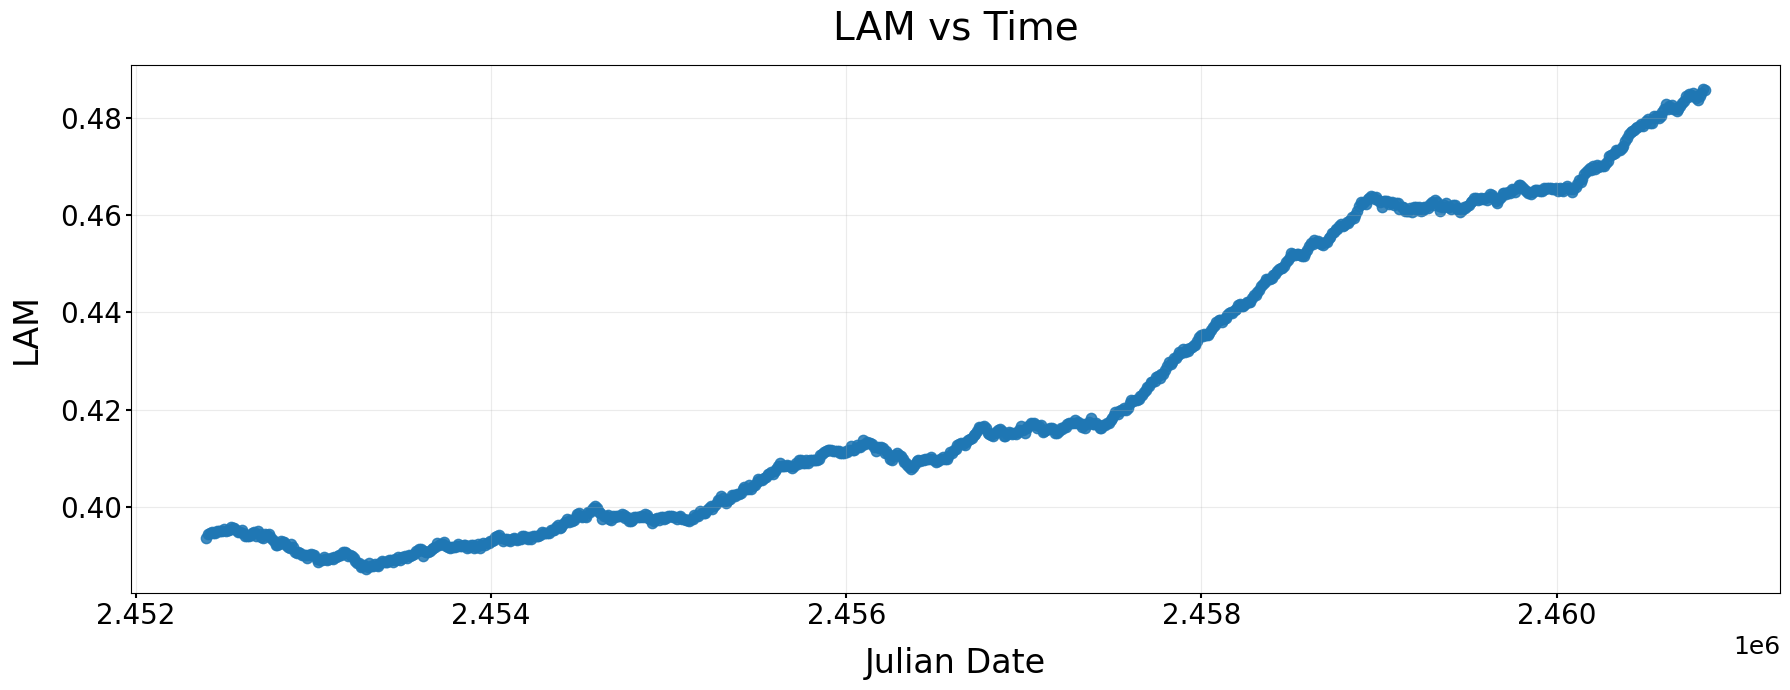


First JD : 2452396.606561
Last JD  : 2460836.008736695


In [12]:
mag_gy=detrend(jd_bined,mag_bined,4)
ews(jd_bined,mag_gy,1900,"T CrB")

For RS Oph 

In [13]:
df=pd.read_csv("RsOph.txt")
print(df.columns)
print(df['Band'].unique())
df1 = df[df["Band"] == "V"]  
df2=df[df["Band"]=="Vis."]
# print(df["Band"].unique())
# df = df[df["Band"] == "Vis." ]
mag_clean = []
jd_clean = []
jd=[]
mag=[]

# Extrecting 
jd1= df1["JD"].tolist()
mag1 = df1["Magnitude"].tolist()
jd2 = df2["JD"].tolist()
mag2 = df2["Magnitude"].tolist()

jd_clean1=[]
mag_clean1=[]

jd_clean2=[]
mag_clean2=[]

#converting data types 
for j, m in zip(jd1, mag1):
    try:
        if isinstance(m, str) and m.strip().startswith('<'):
            m = float(m.strip()[1:])  # remove '<'
        else:
            m = float(m)
        jd_clean1.append(float(j))
        mag_clean1.append(m)
    except:
        continue
for j, m in zip(jd2, mag2):
    try:
        if isinstance(m, str) and m.strip().startswith('<'):
            m = float(m.strip()[1:])  # remove '<'
        else:
            m = float(m)
        jd_clean2.append(float(j))
        mag_clean2.append(m)
    except:
        continue
jd_clean=jd_clean1+jd_clean2
mag_clean=mag_clean1+mag_clean2

#correcting time scale 
# jd_clean = [x - 2440000 for x in jd_clean]

# Zip JD and mag together, sort by JD
sorted_pairs = sorted(zip(jd_clean, mag_clean))

# Unzip the sorted pairs back to separate lists
jd_sorted, mag_sorted = zip(*sorted_pairs)

# Convert back to lists if needed
jd_clean = list(jd_sorted)
mag_clean = list(mag_sorted)

C:\Users\hp\AppData\Local\Temp\ipykernel_12772\2598125398.py:1: DtypeWarning: Columns (12,20,21,22) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("RsOph.txt")


Index(['JD', 'Magnitude', 'Uncertainty', 'HQuncertainty', 'Band',
       'Observer Code', 'Comment Code(s)', 'Comp Star 1', 'Comp Star 2',
       'Charts', 'Comments', 'Transfomed', 'Airmass', 'Validation Flag',
       'Cmag', 'Kmag', 'HJD', 'Star Name', 'Observer Affiliation',
       'Measurement Method', 'Grouping Method', 'ADS Reference', 'Digitizer',
       'Credit'],
      dtype='object')
['Vis.' nan 'V' 'U' 'Green-Vis.' 'CV' 'CR' 'B' 'I' 'R' 'H' 'J' 'RJ' 'TG'
 'TB' 'TR' 'ZS' 'SR' 'SG']


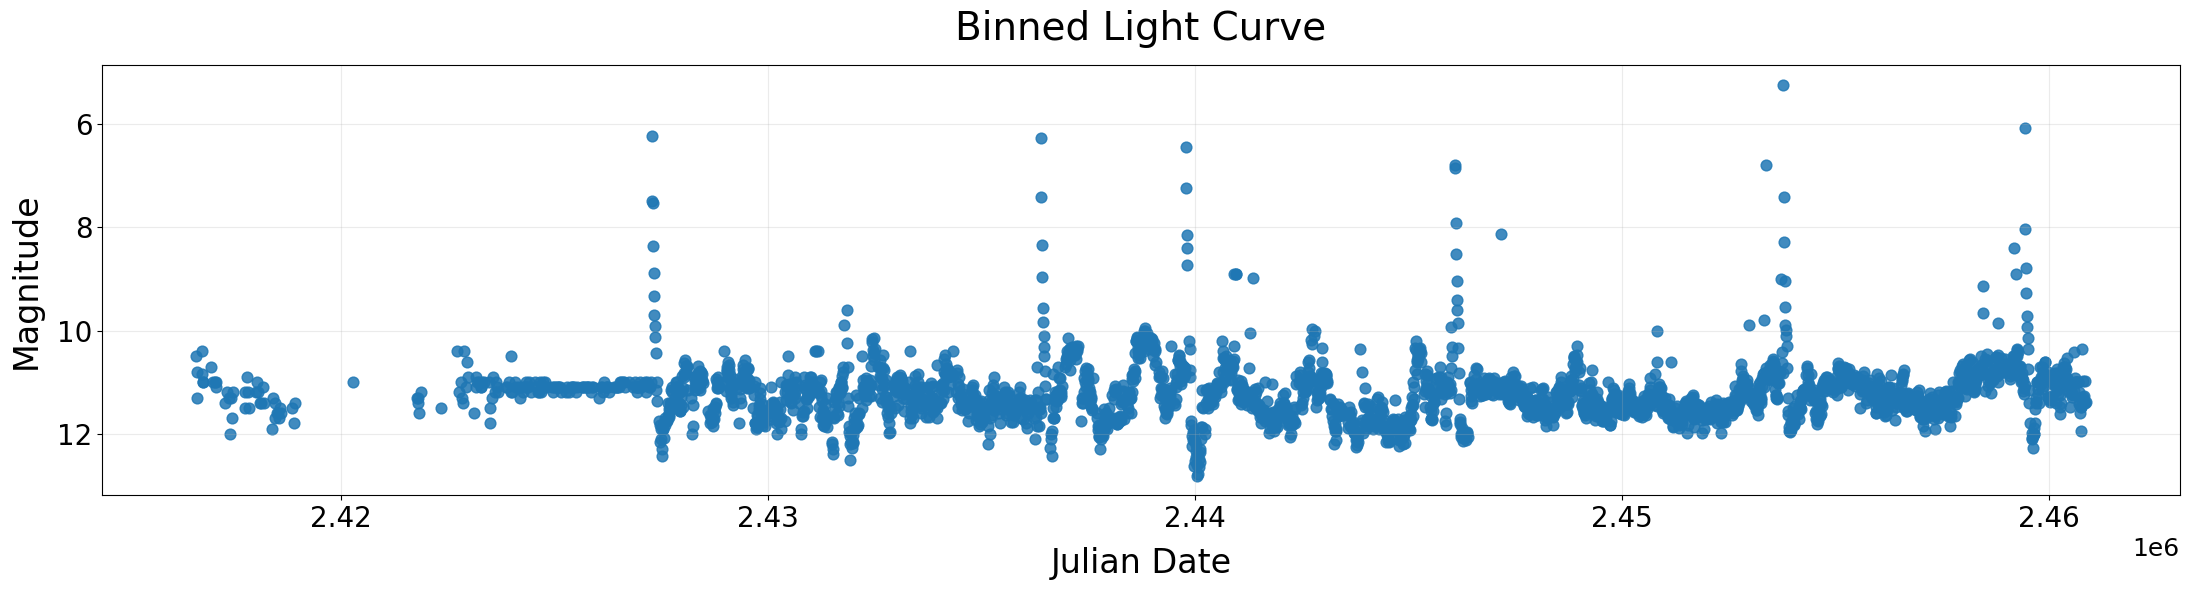

Start JD : 2416625.8
End JD   : 2460856.8881245335


In [14]:
jdf = jd_clean[:]
magf = mag_clean[:]

# Bin data
jd_bined, mag_bined = bin_by_days(
    jdf,
    magf,
    bin_width=10
)

# Plot
fig, ax = plt.subplots(figsize=(22, 6))

ax.scatter(
    jd_bined,
    mag_bined,
    s=60,
    alpha=0.85
)

ax.set_title("Binned Light Curve", fontsize=28, pad=18)
ax.set_xlabel("Julian Date", fontsize=24, labelpad=10)
ax.set_ylabel("Magnitude", fontsize=24, labelpad=10)

# Tick styling
ax.tick_params(axis='both', labelsize=20)

# Increase 10^6 font size
ax.xaxis.get_offset_text().set_fontsize(18)

# Astronomy convention
ax.invert_yaxis()

# Grid
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

print("Start JD :", jd_bined[0])
print("End JD   :", jd_bined[-1])

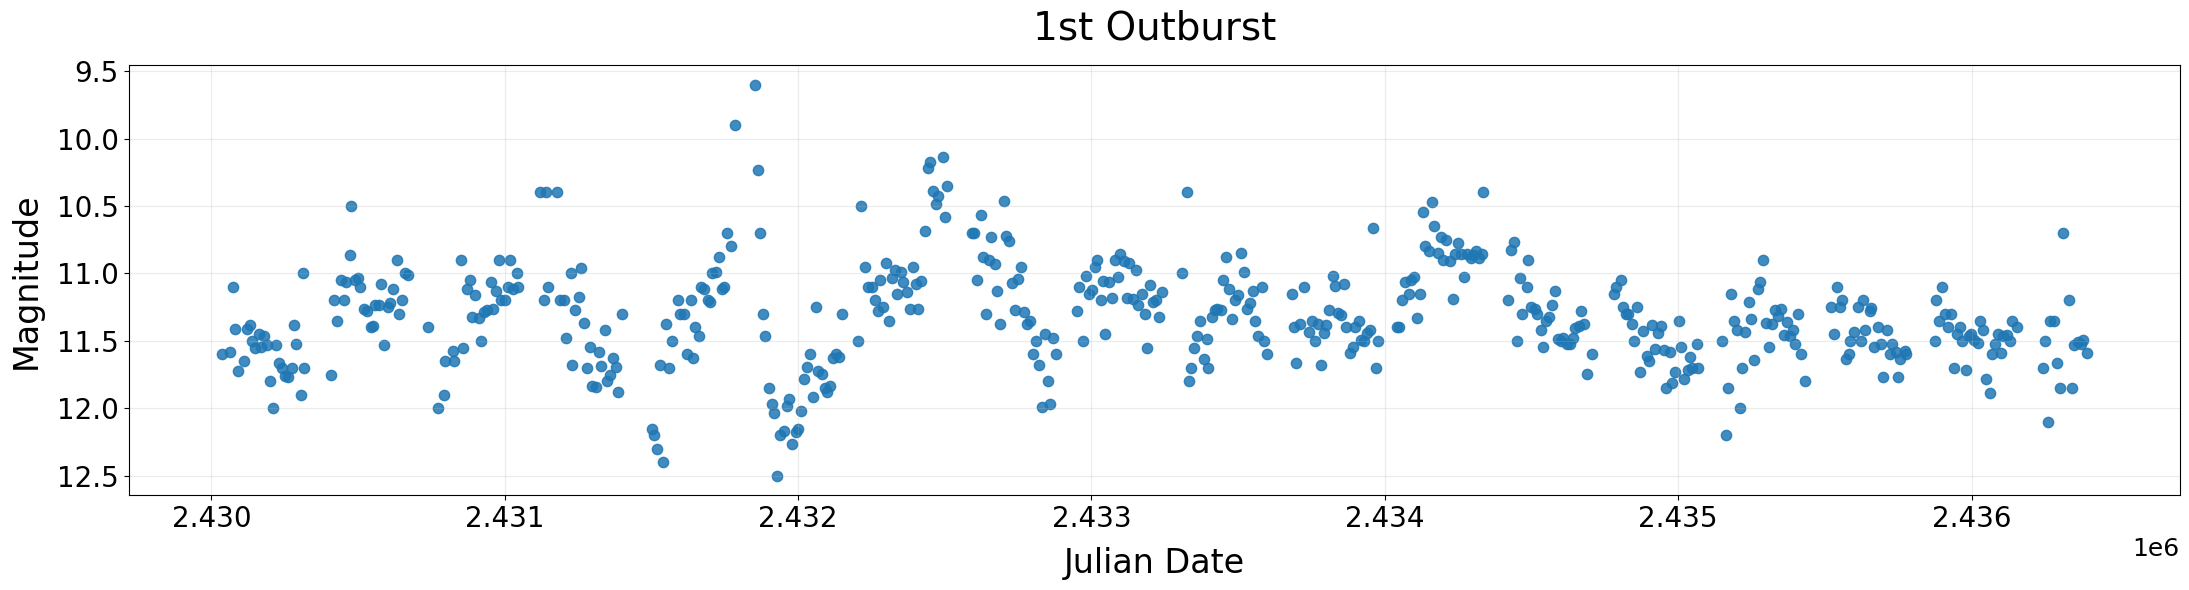

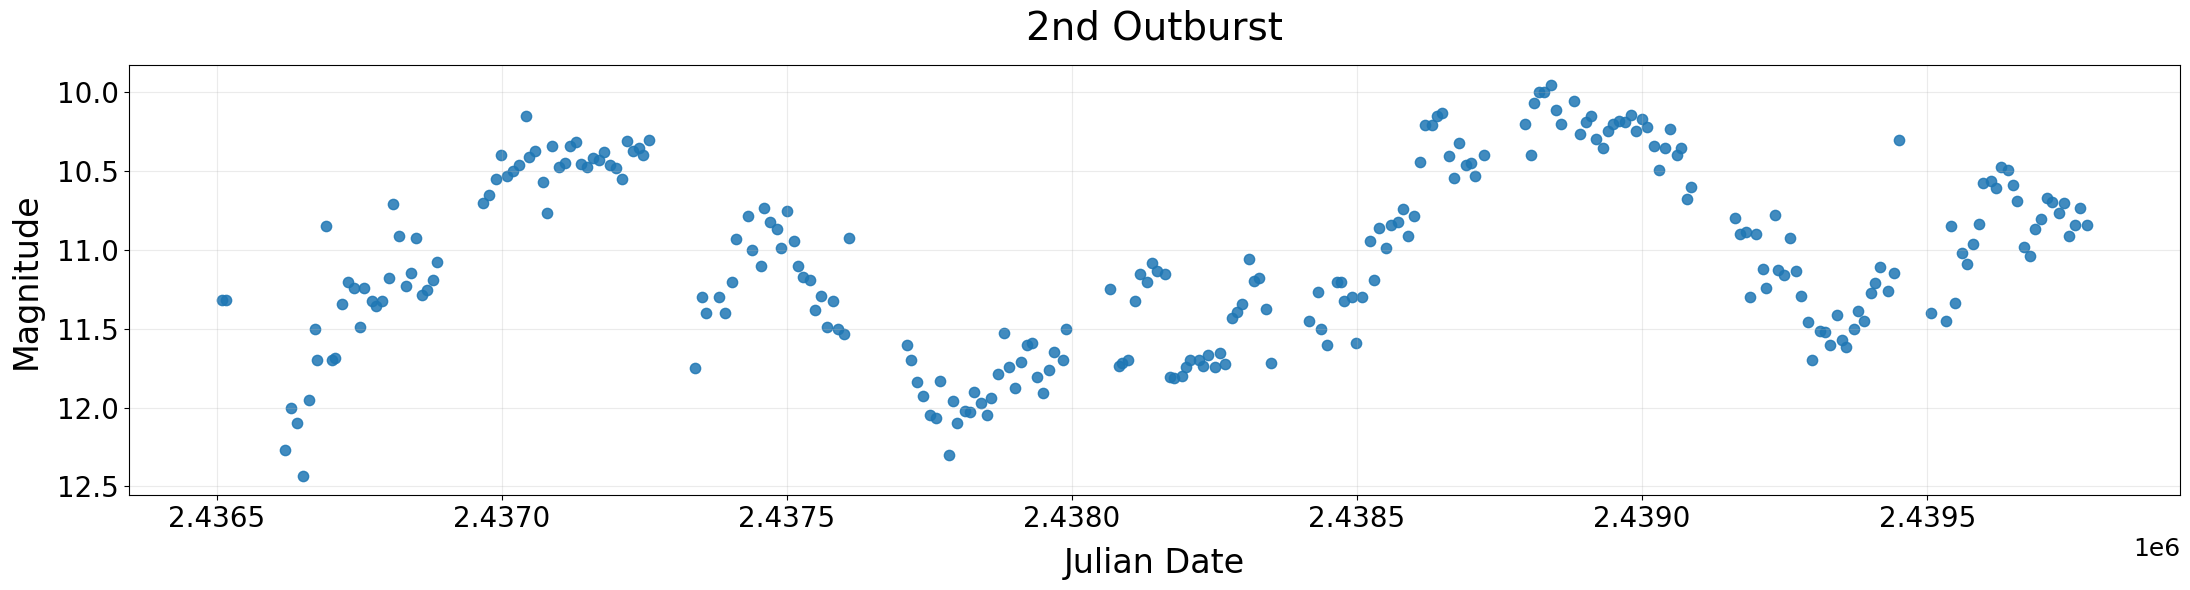

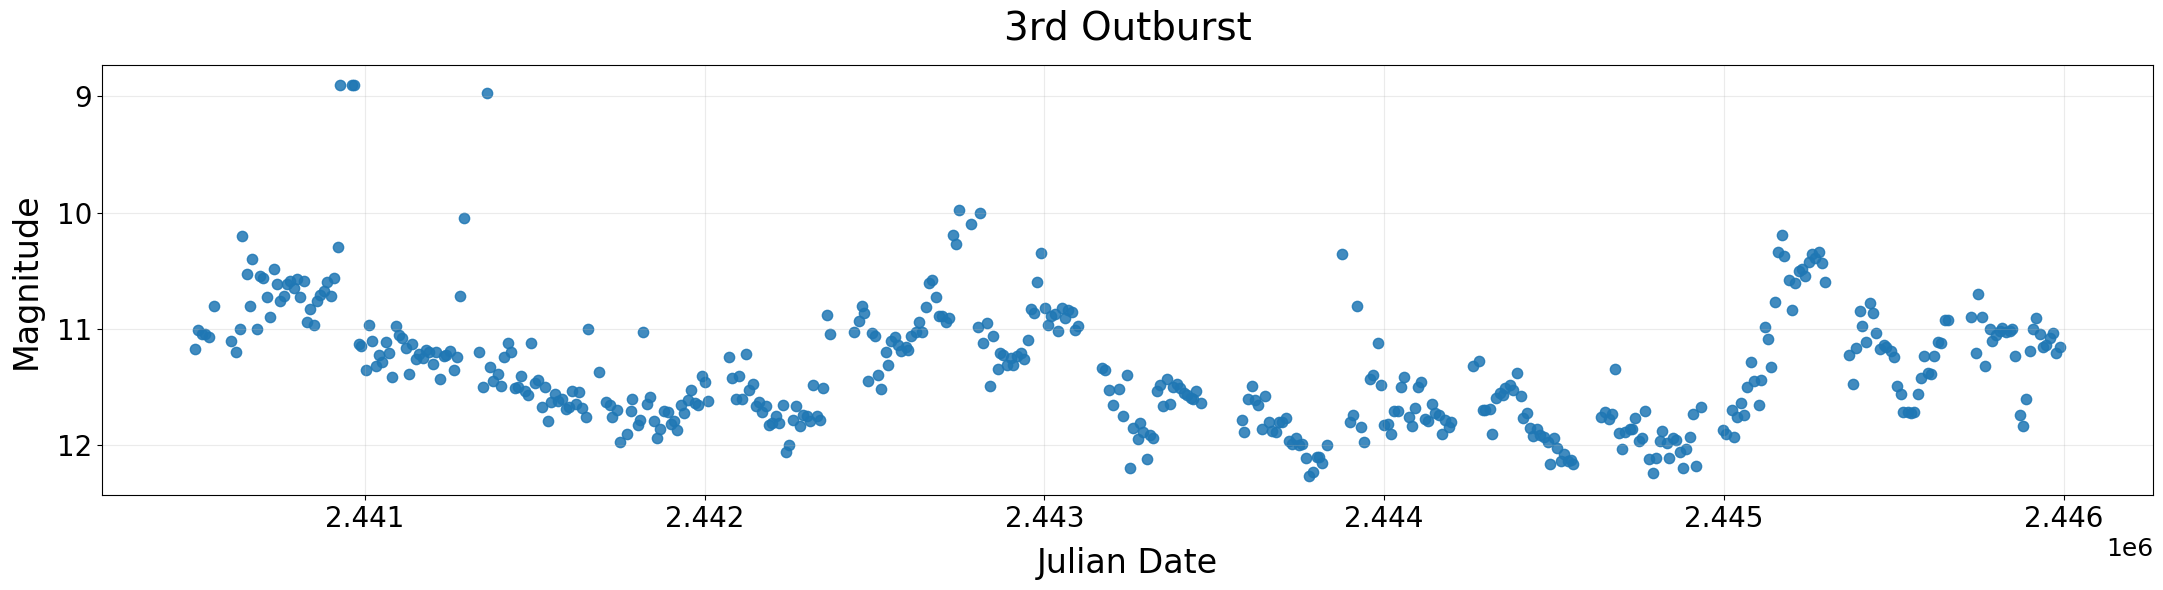

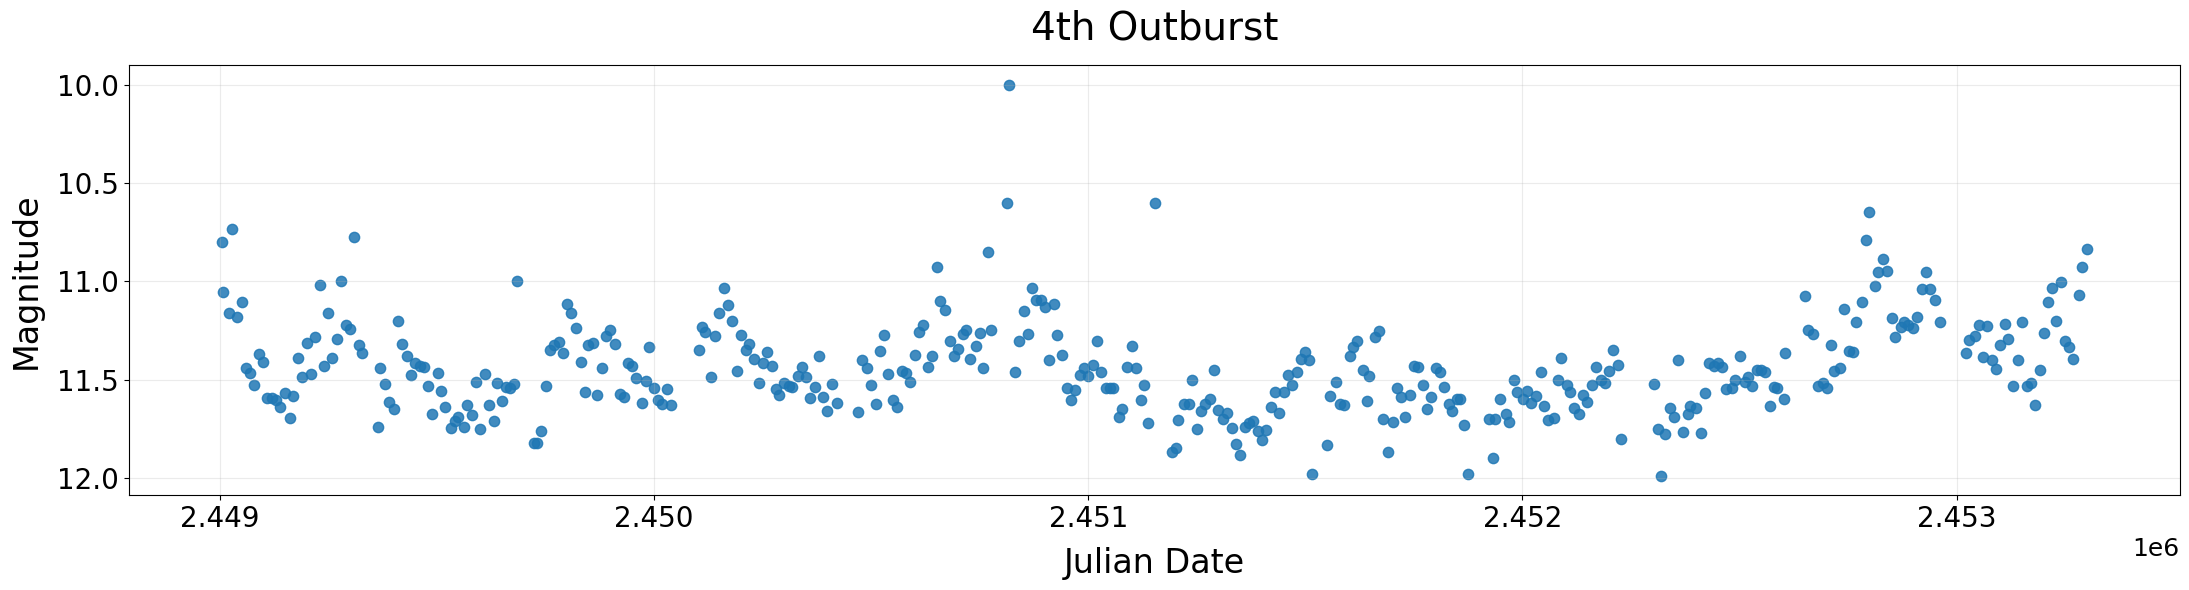

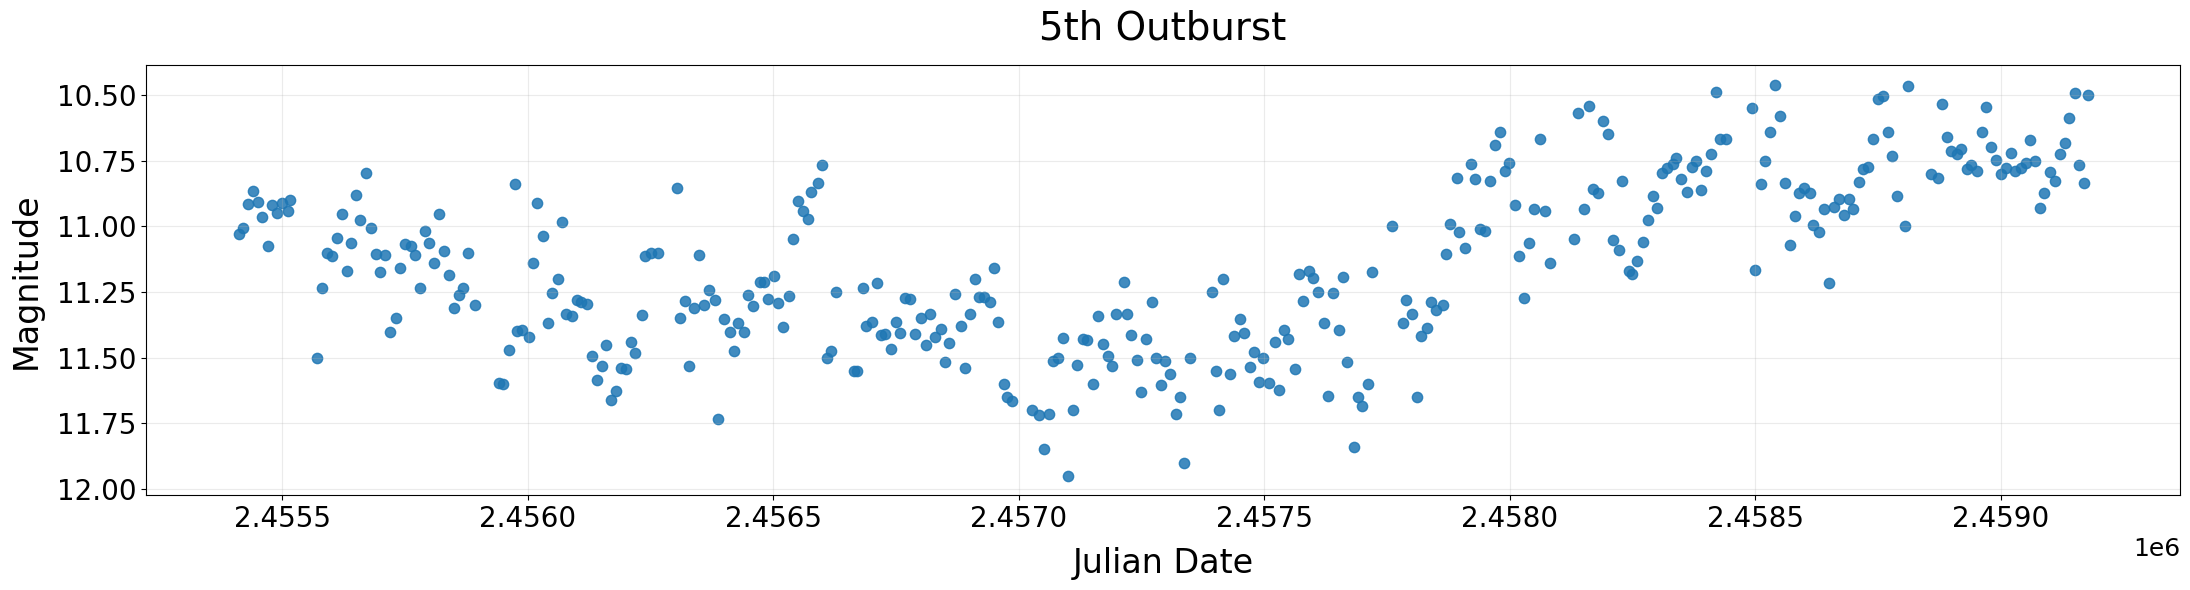

In [15]:
import matplotlib.pyplot as plt
import numpy as np


def plot_outburst(jd, mag, title):
    fig, ax = plt.subplots(figsize=(22, 6))

    ax.scatter(
        jd,
        mag,
        s=55,
        alpha=0.85
    )

    ax.set_title(title, fontsize=28, pad=18)
    ax.set_xlabel("Julian Date", fontsize=24, labelpad=10)
    ax.set_ylabel("Magnitude", fontsize=24, labelpad=10)

    ax.tick_params(axis='both', labelsize=20)

    # Increase 10^6 font
    ax.xaxis.get_offset_text().set_fontsize(18)

    # Astronomy convention
    ax.invert_yaxis()

    ax.grid(alpha=0.25)

    plt.tight_layout()
    plt.show()


# -----------------------------------
# 1st Outburst
# -----------------------------------
jd_first = []
mag_first = []

for jd, mag in zip(jd_bined, mag_bined):
    if 2430000 <= jd < 2436400 and mag >= 7:
        jd_first.append(jd)
        mag_first.append(mag)

plot_outburst(jd_first, mag_first, "1st Outburst")


# -----------------------------------
# 2nd Outburst
# -----------------------------------
jd_second = []
mag_second = []

for jd, mag in zip(jd_bined, mag_bined):
    if 2436500 <= jd < 2439790:
        jd_second.append(jd)
        mag_second.append(mag)

plot_outburst(jd_second, mag_second, "2nd Outburst")


# -----------------------------------
# 3rd Outburst
# -----------------------------------
jd_third = []
mag_third = []

for jd, mag in zip(jd_bined, mag_bined):
    if 2440500 <= jd < 2446000:
        jd_third.append(jd)
        mag_third.append(mag)

plot_outburst(jd_third, mag_third, "3rd Outburst")


# -----------------------------------
# 4th Outburst
# -----------------------------------
jd_fourth = []
mag_fourth = []

for jd, mag in zip(jd_bined, mag_bined):
    if 2449000 <= jd < 2453300 and mag >= 10:
        jd_fourth.append(jd)
        mag_fourth.append(mag)

plot_outburst(jd_fourth, mag_fourth, "4th Outburst")


# -----------------------------------
# 5th Outburst
# -----------------------------------
jd_fifth = []
mag_fifth = []

for jd, mag in zip(jd_bined, mag_bined):
    if 2455400 <= jd < 2459180 and mag >= 10:
        jd_fifth.append(jd)
        mag_fifth.append(mag)

plot_outburst(jd_fifth, mag_fifth, "5th Outburst")

Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...


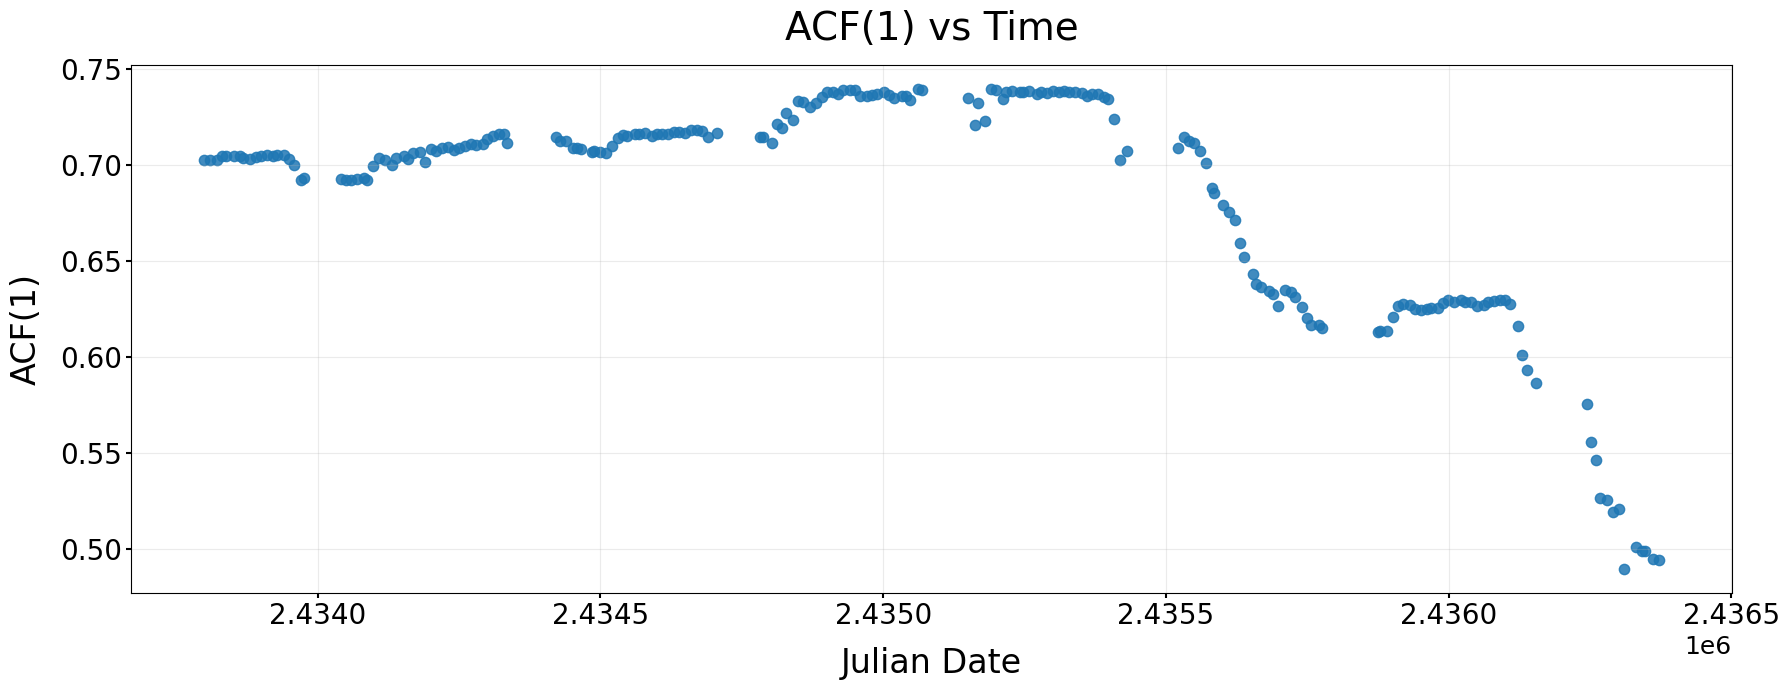

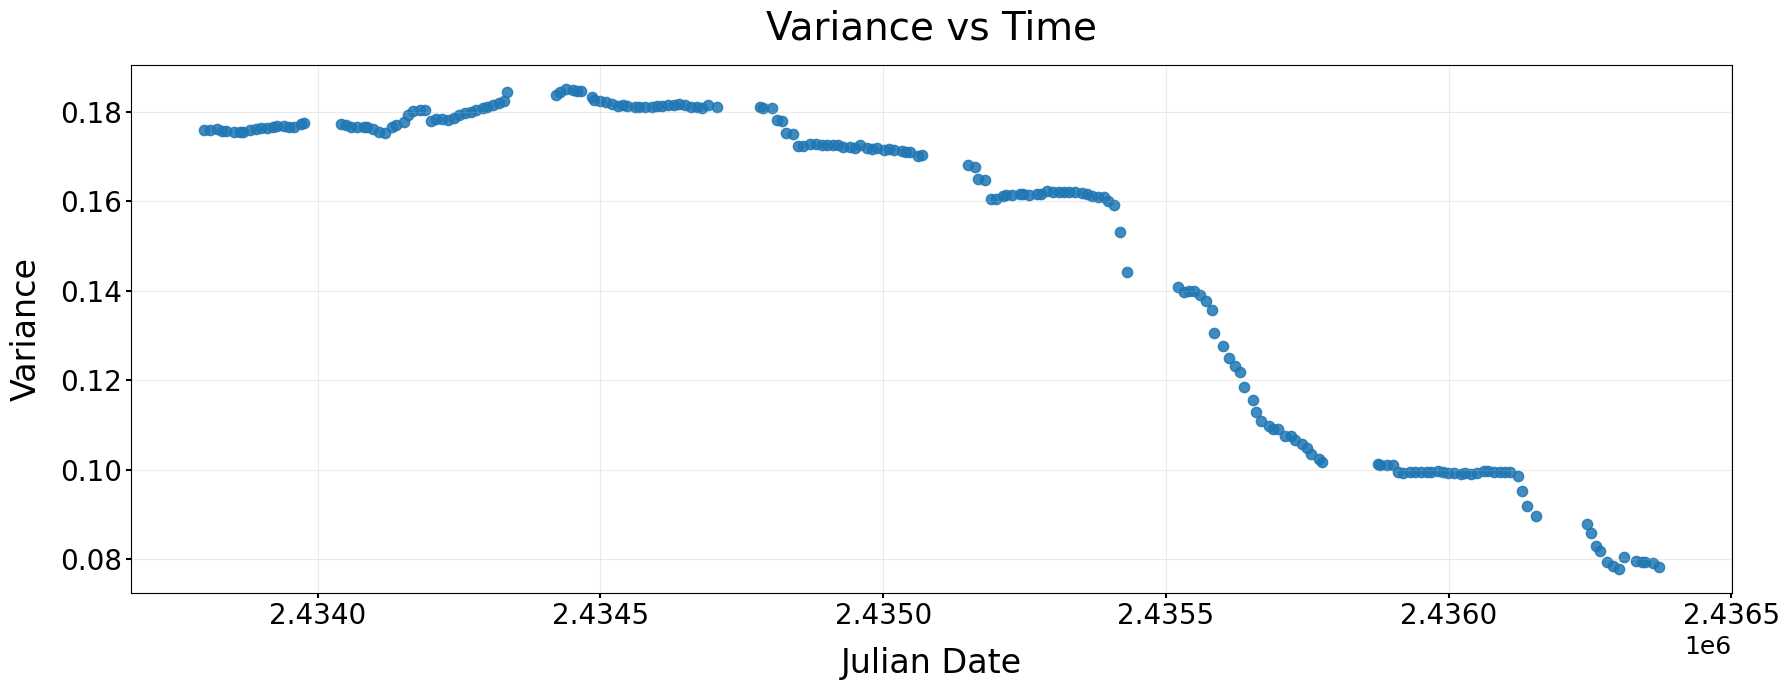

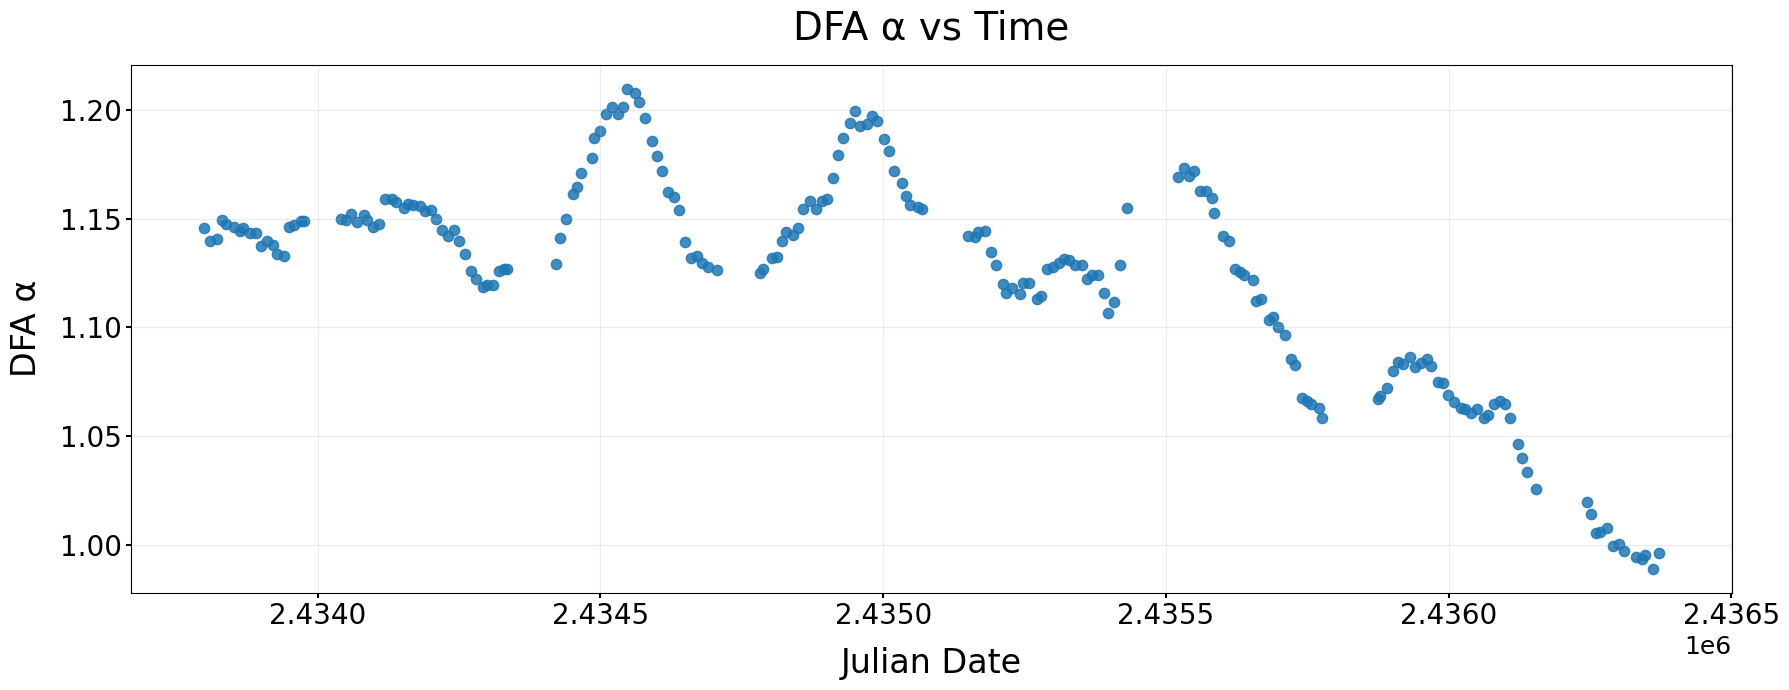

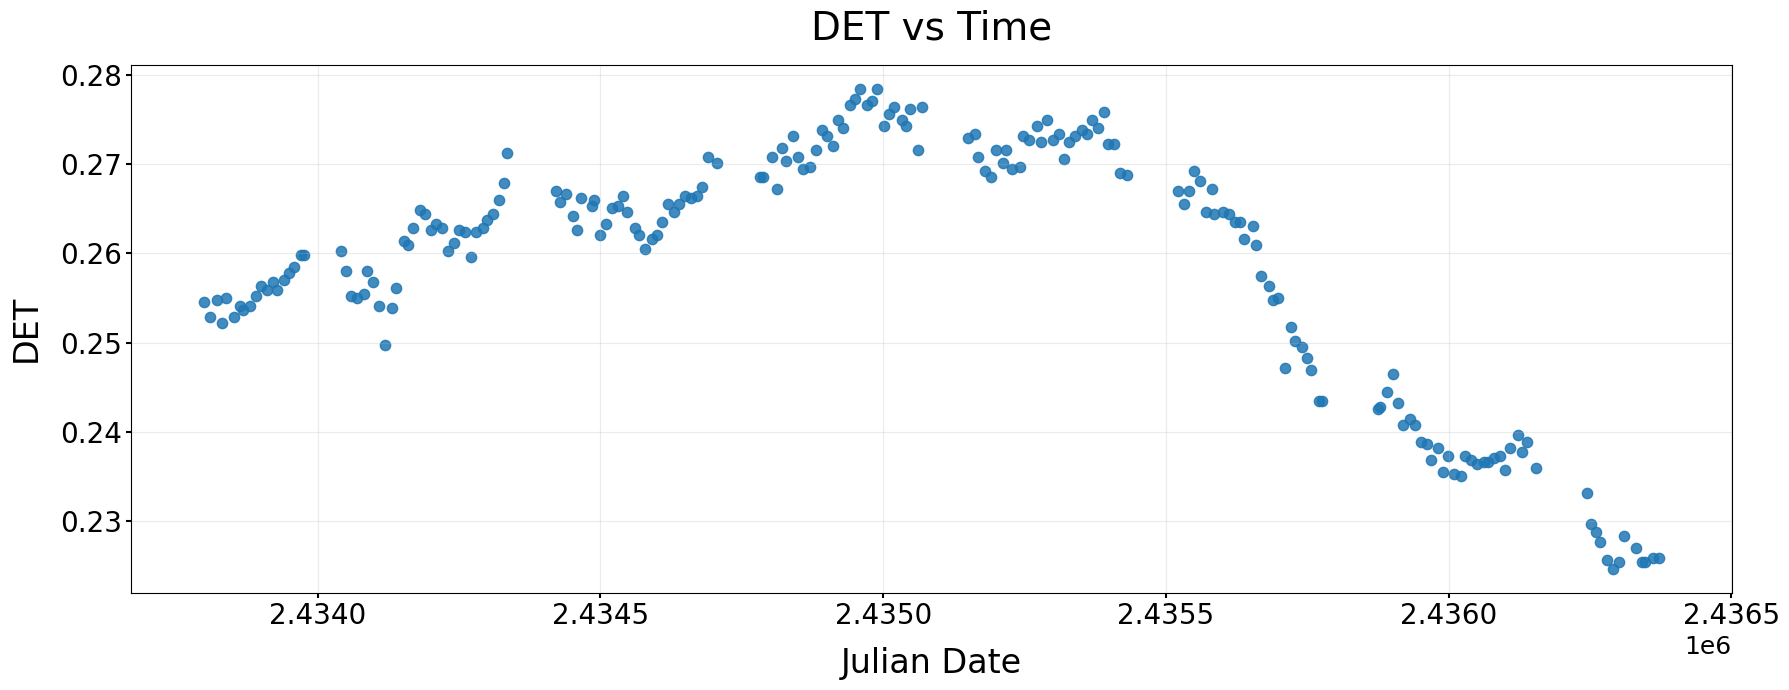

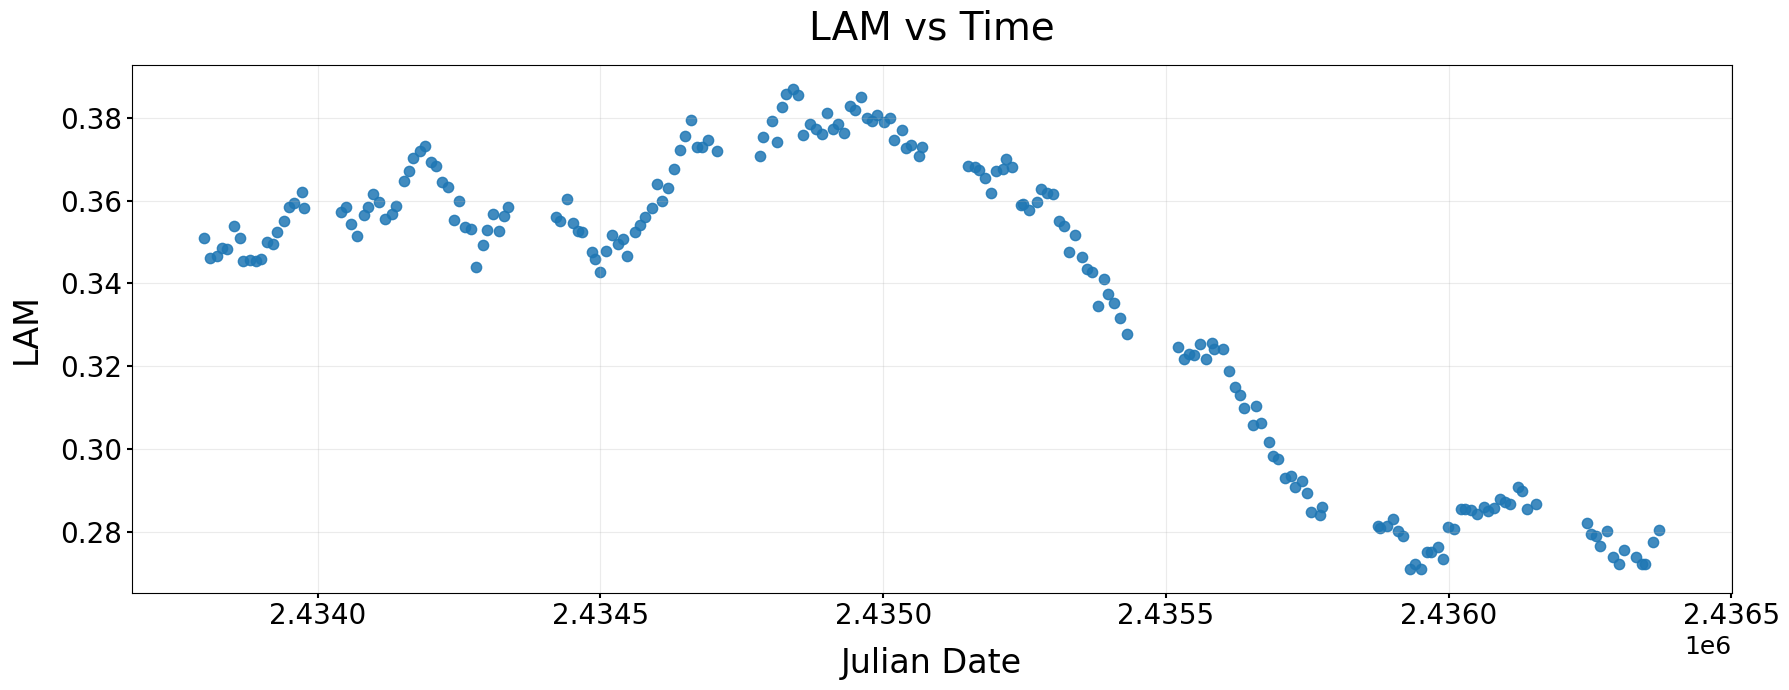


First JD : 2433799.2890000003
Last JD  : 2436372.0444444446


In [16]:
mag_gy=detrend(jd_first,mag_first,3)
ews(jd_first,mag_gy,300,"First Outburst RS Oph")


Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...


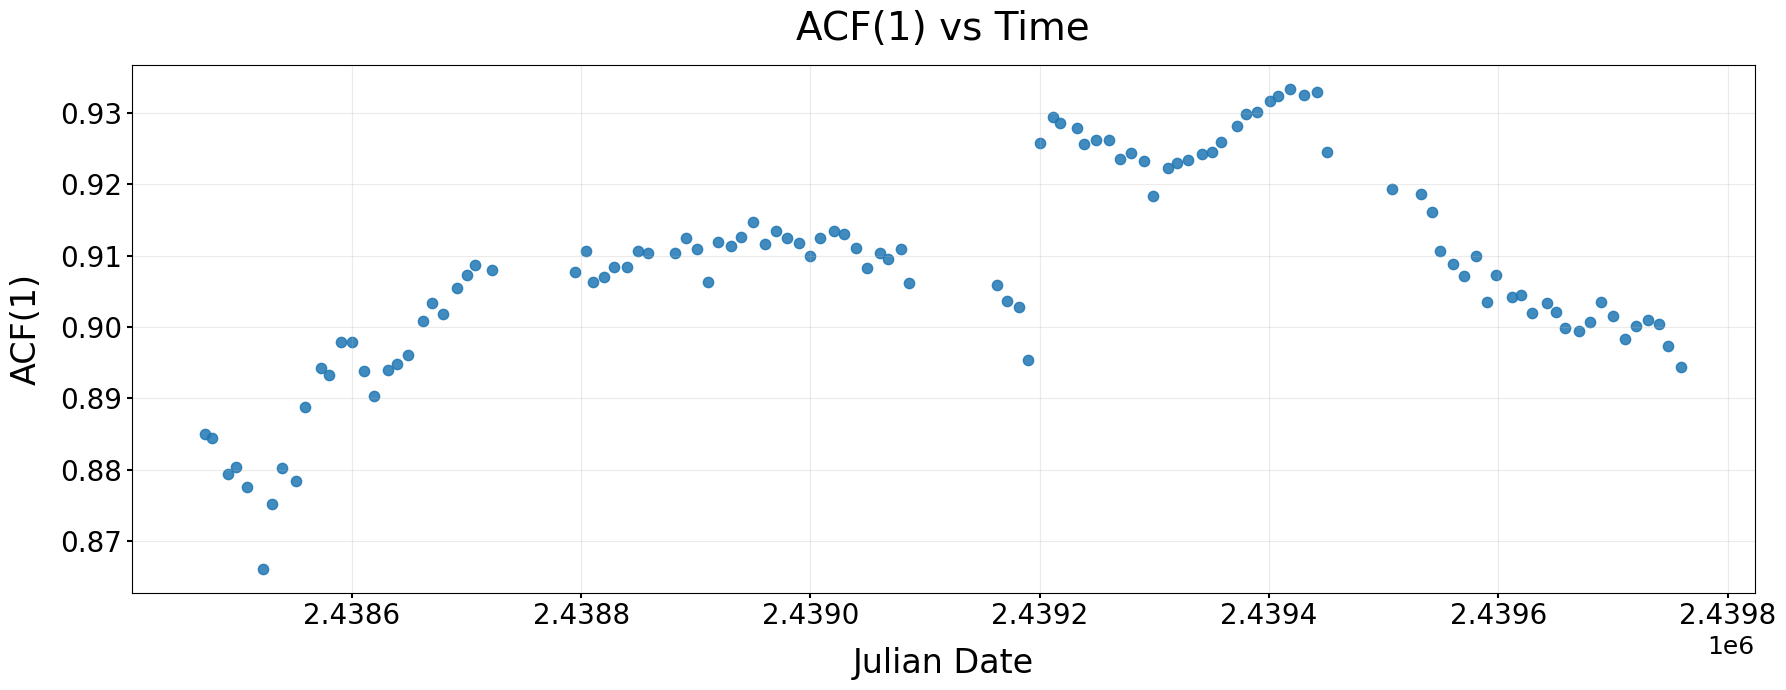

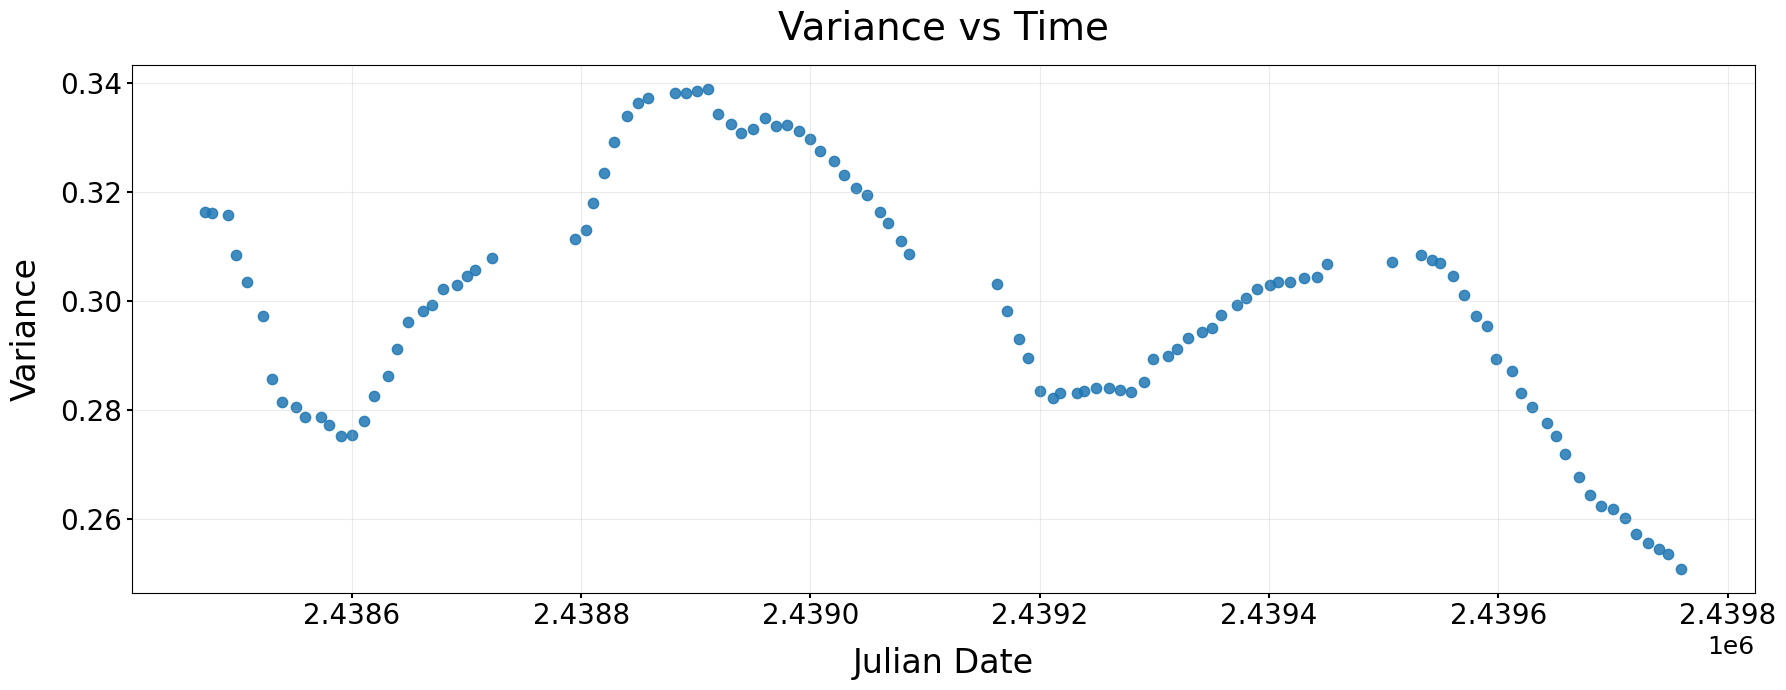

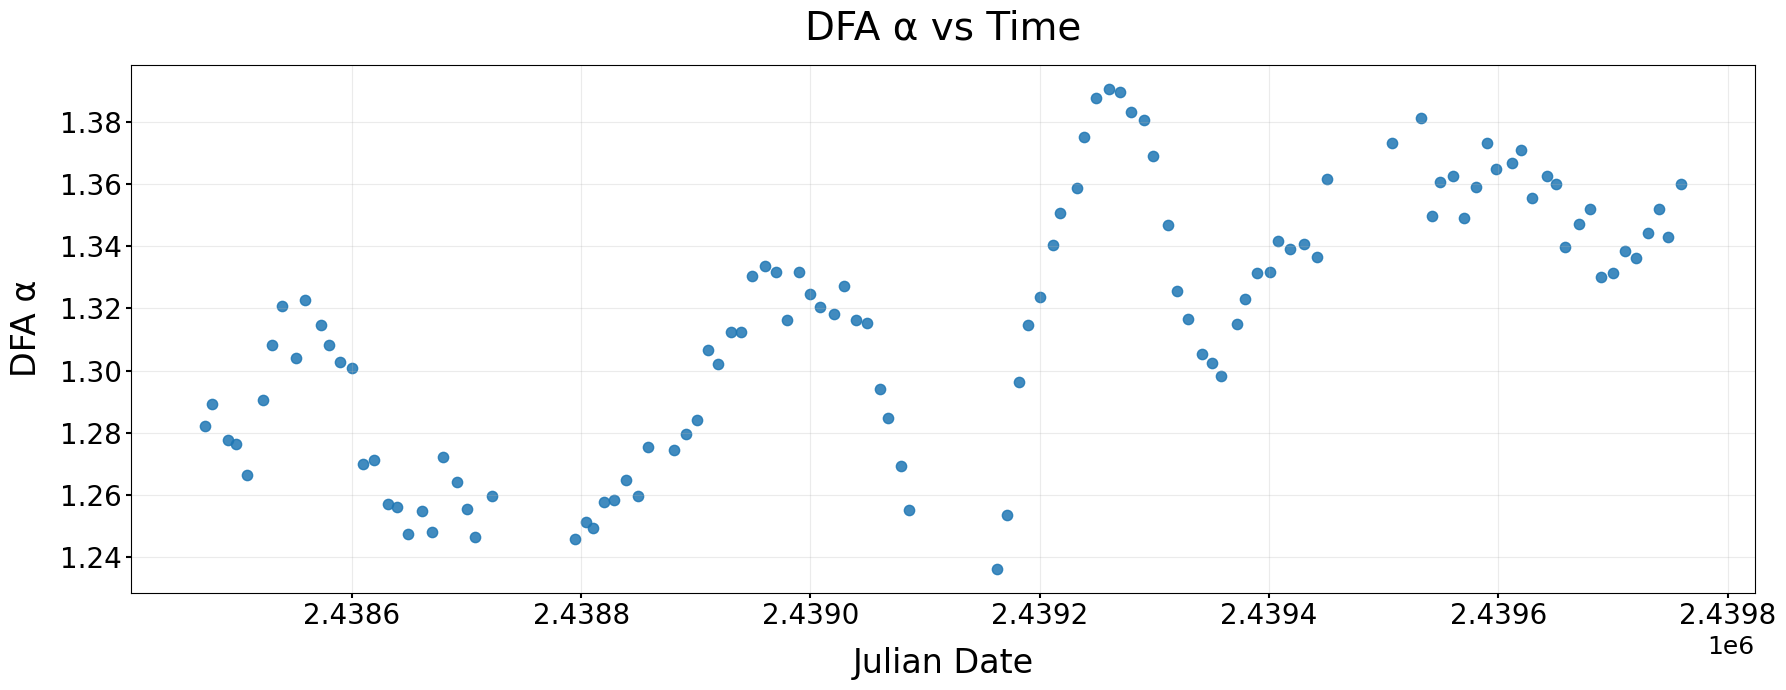

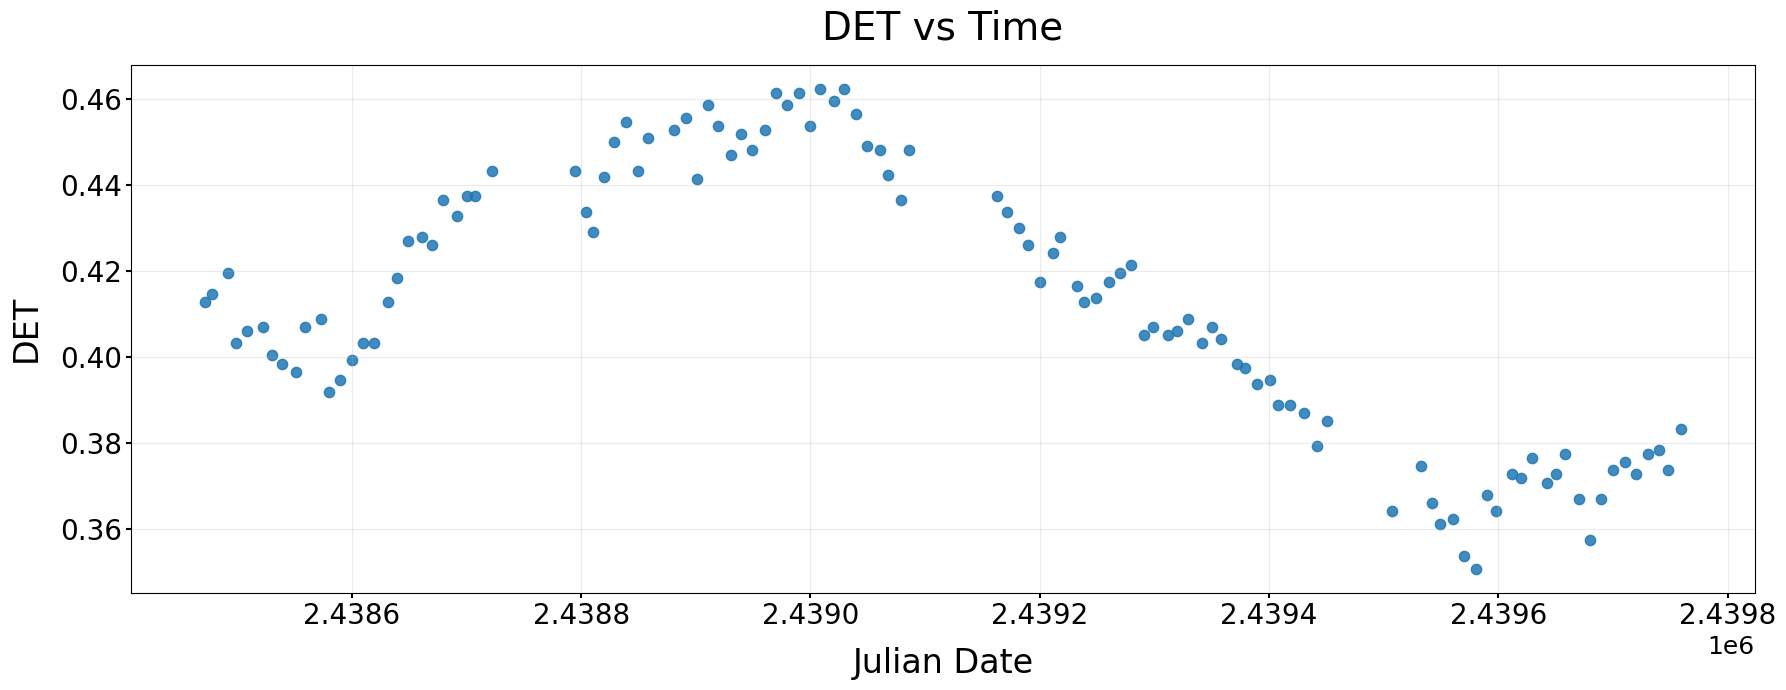

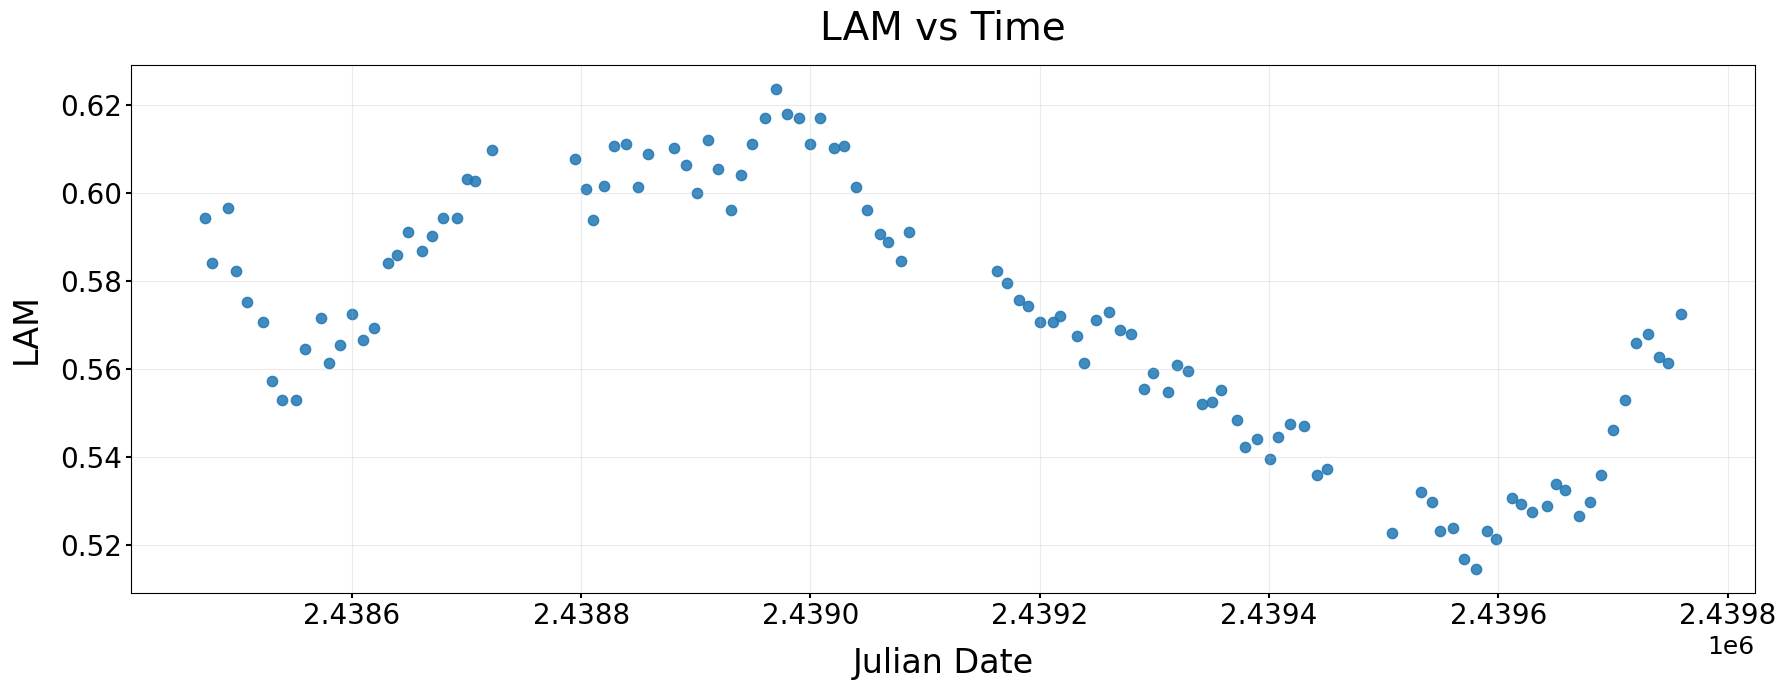


First JD : 2438472.0999999996
Last JD  : 2439759.4626428573


In [17]:
mag_gy=detrend(jd_second,mag_second,3)
ews(jd_second,mag_gy,150,"Second Outburst RS Oph")

Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...


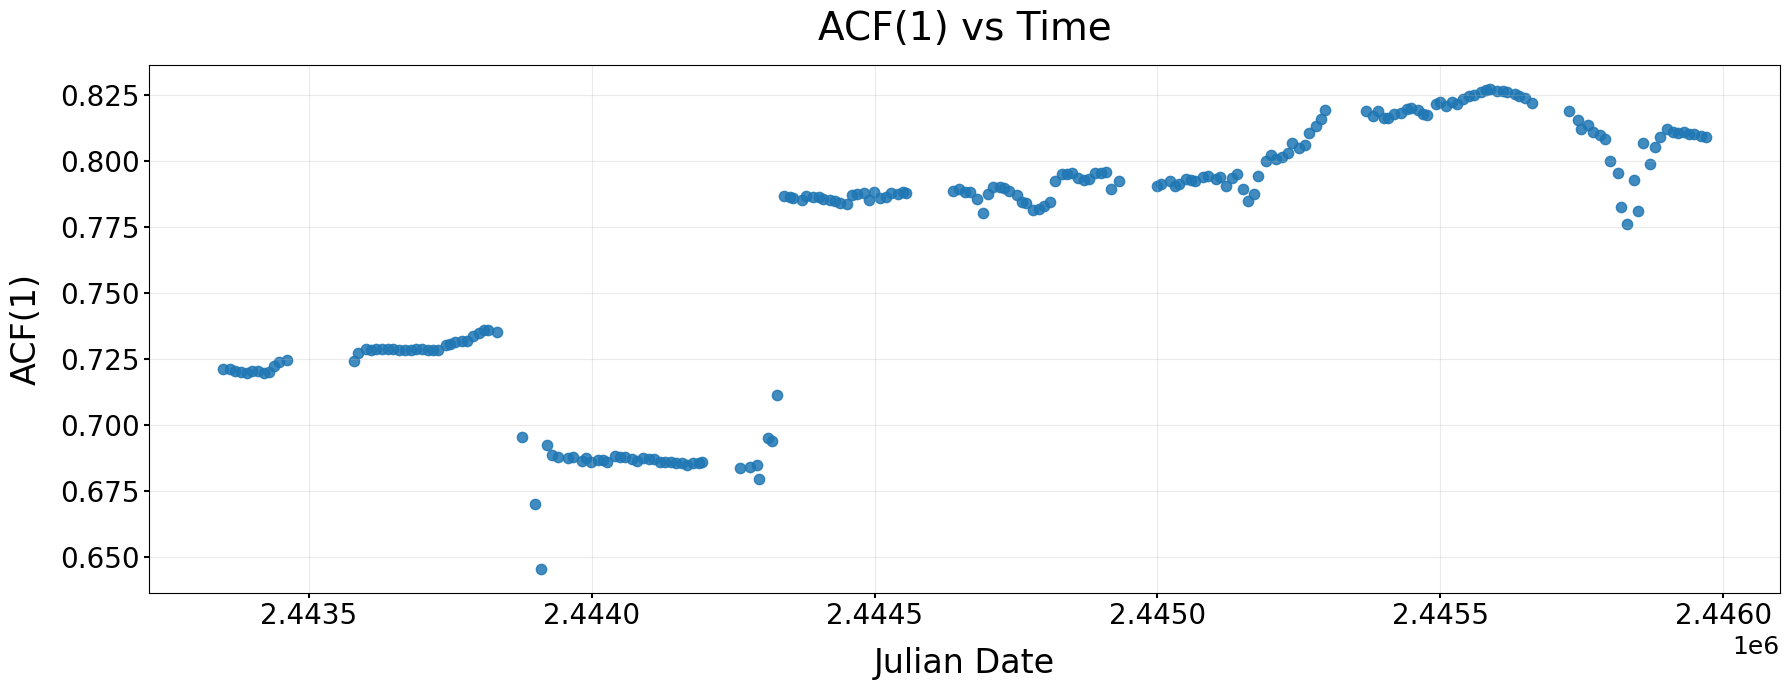

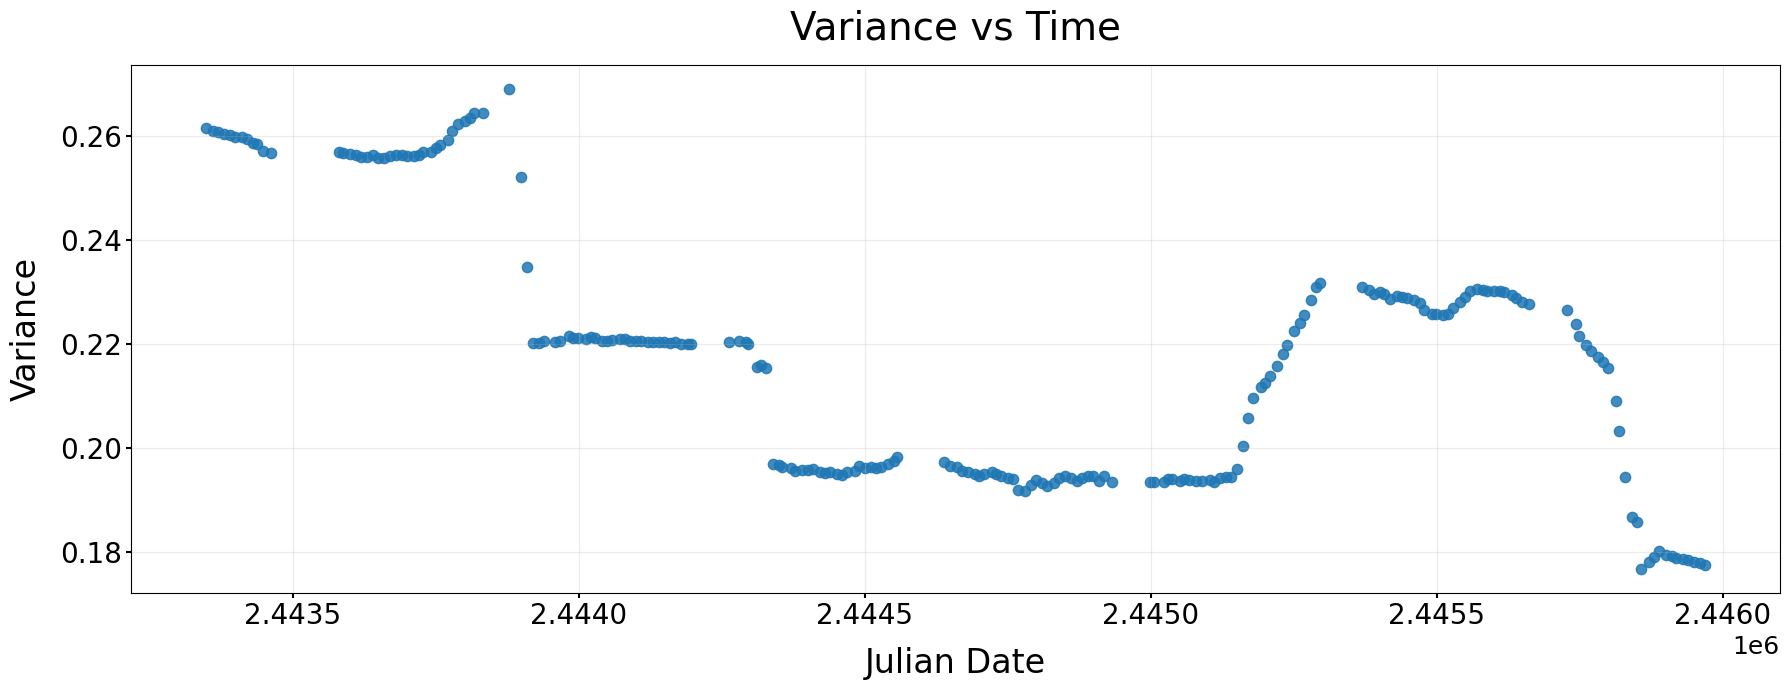

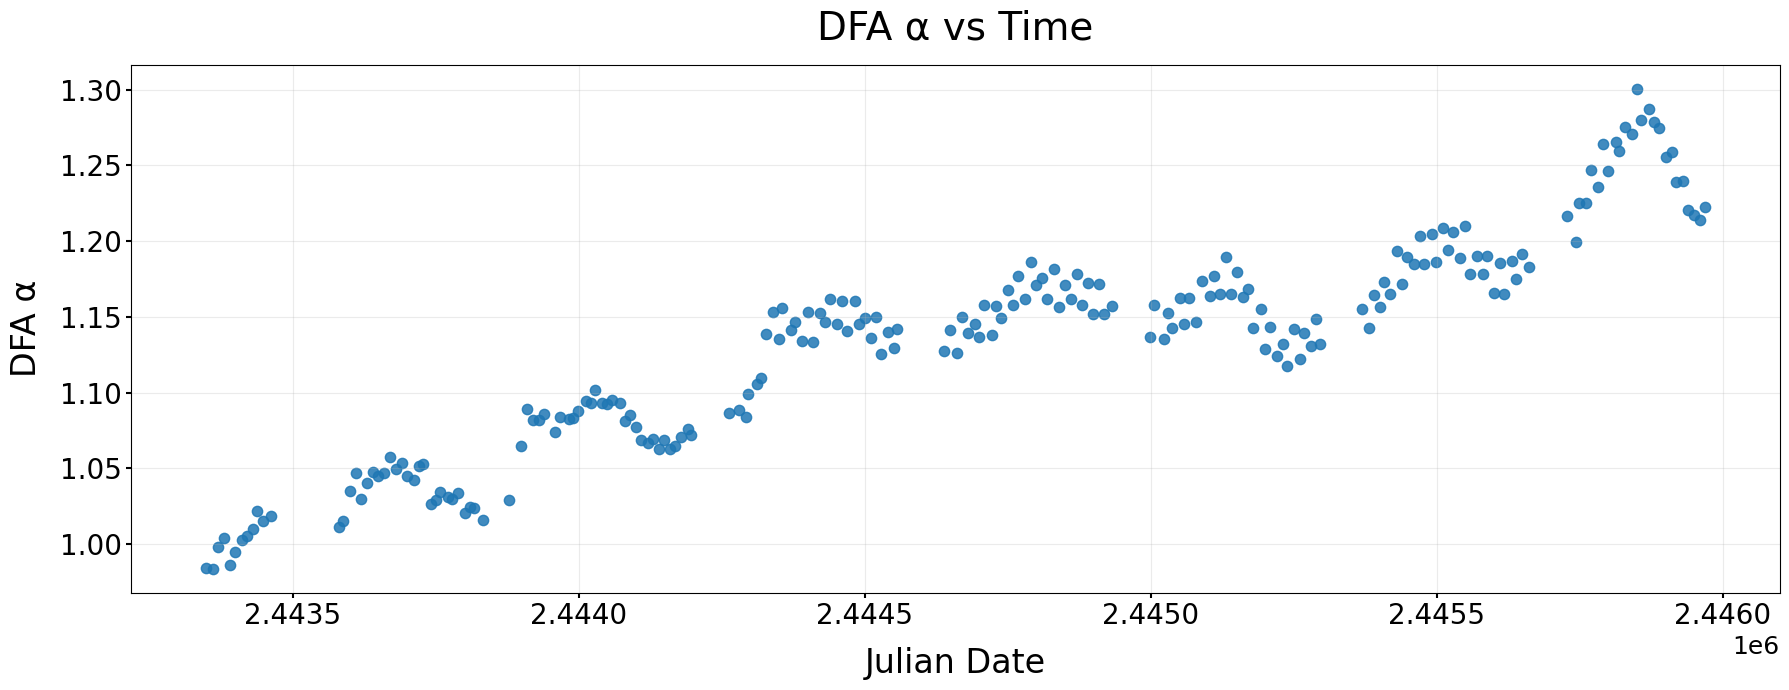

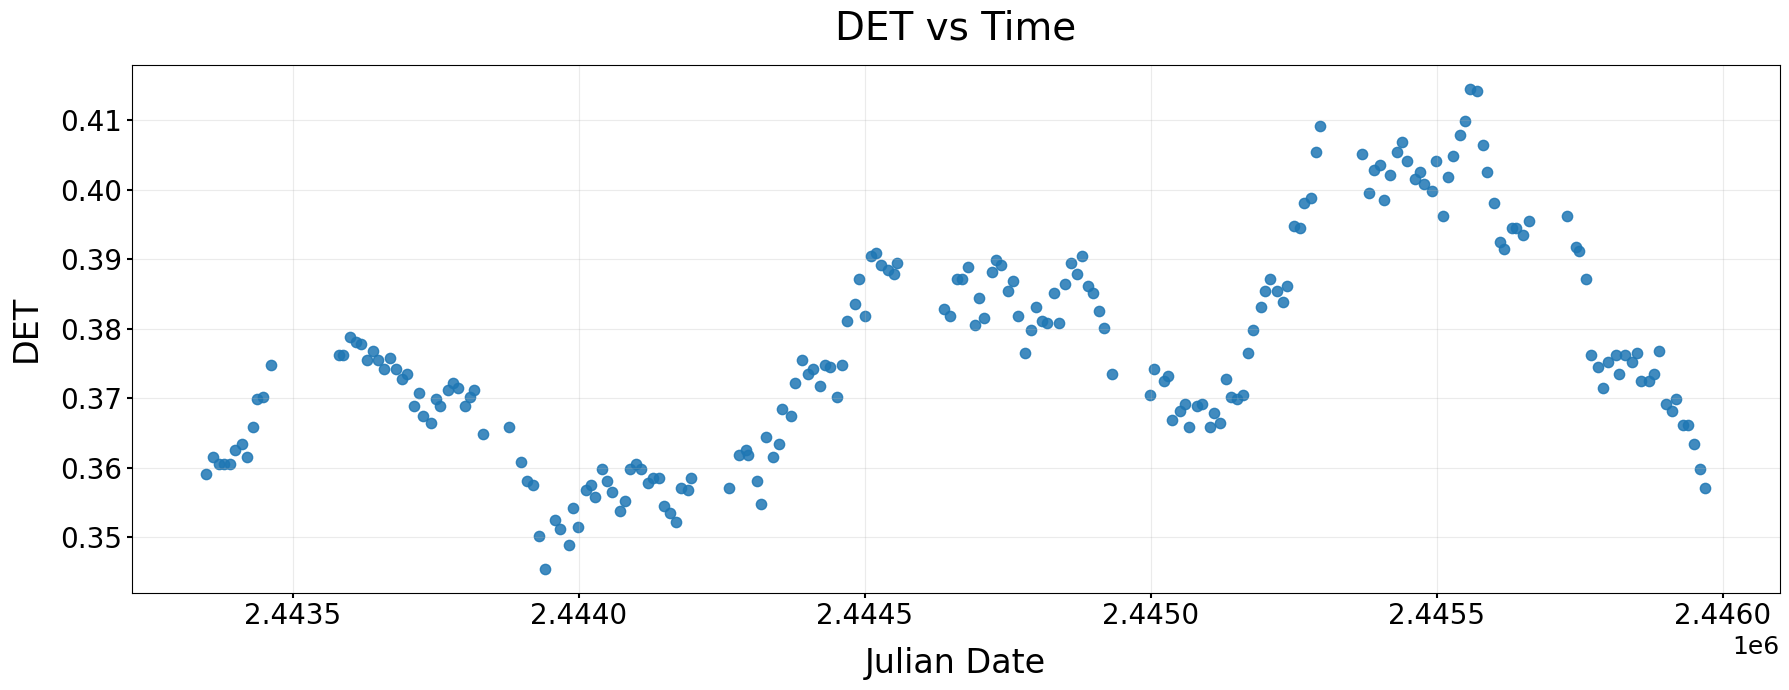

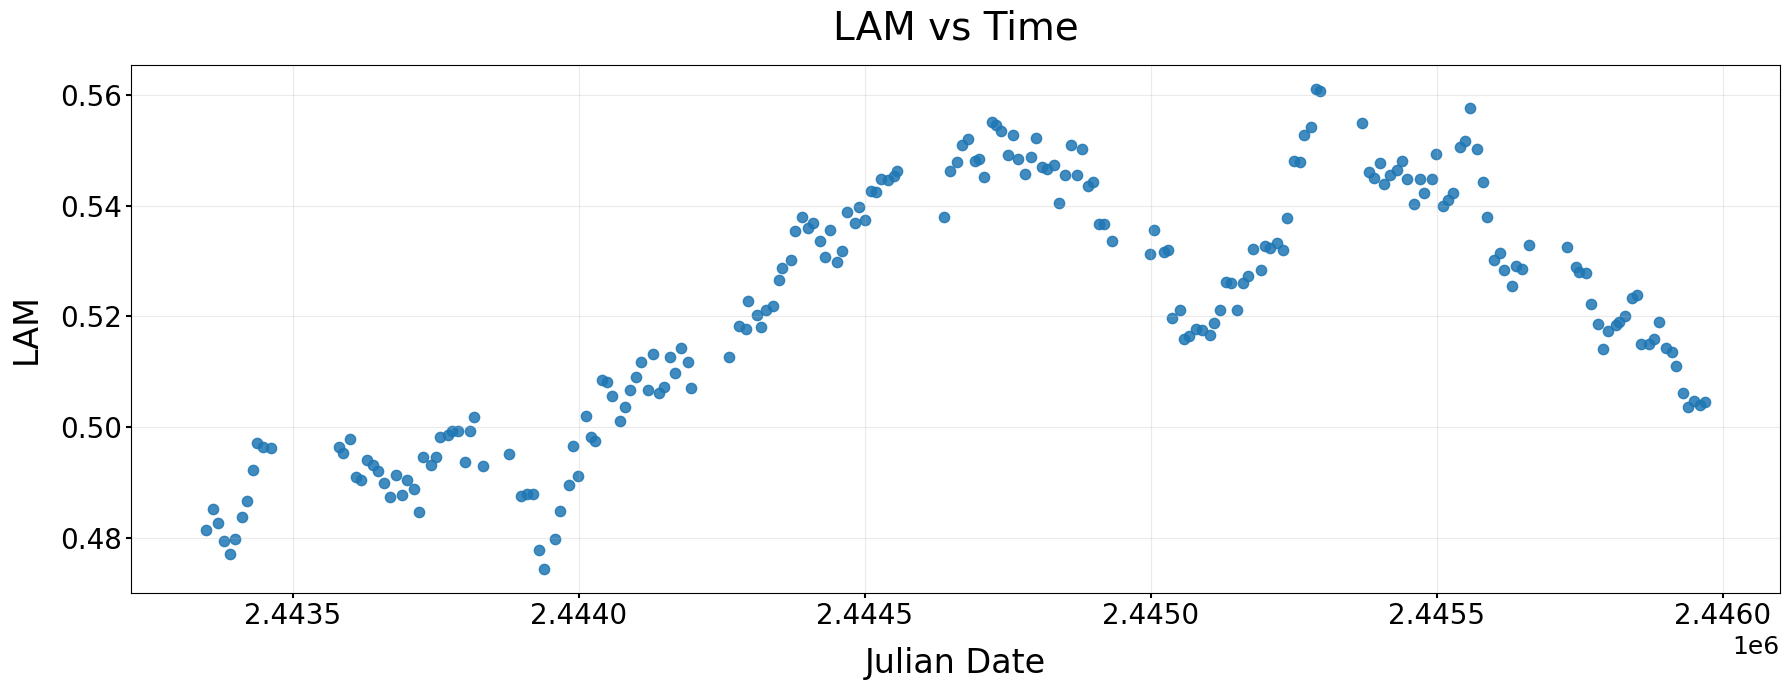


First JD : 2443348.939239131
Last JD  : 2445968.8999333326


In [18]:
mag_gy=detrend(jd_third,mag_third,3)
ews(jd_third,mag_gy,250,"Third Outburst RS Oph")

Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...


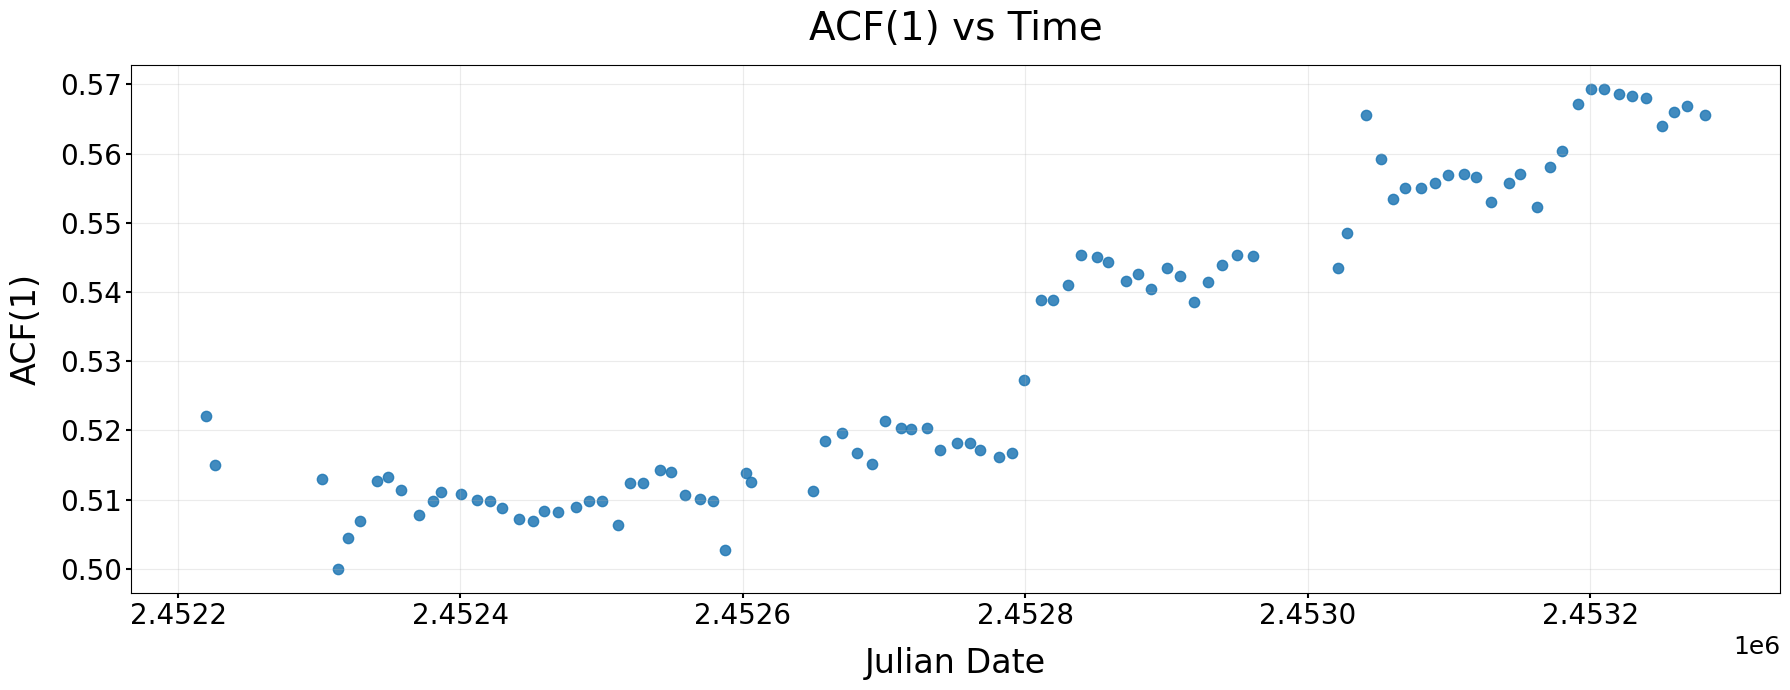

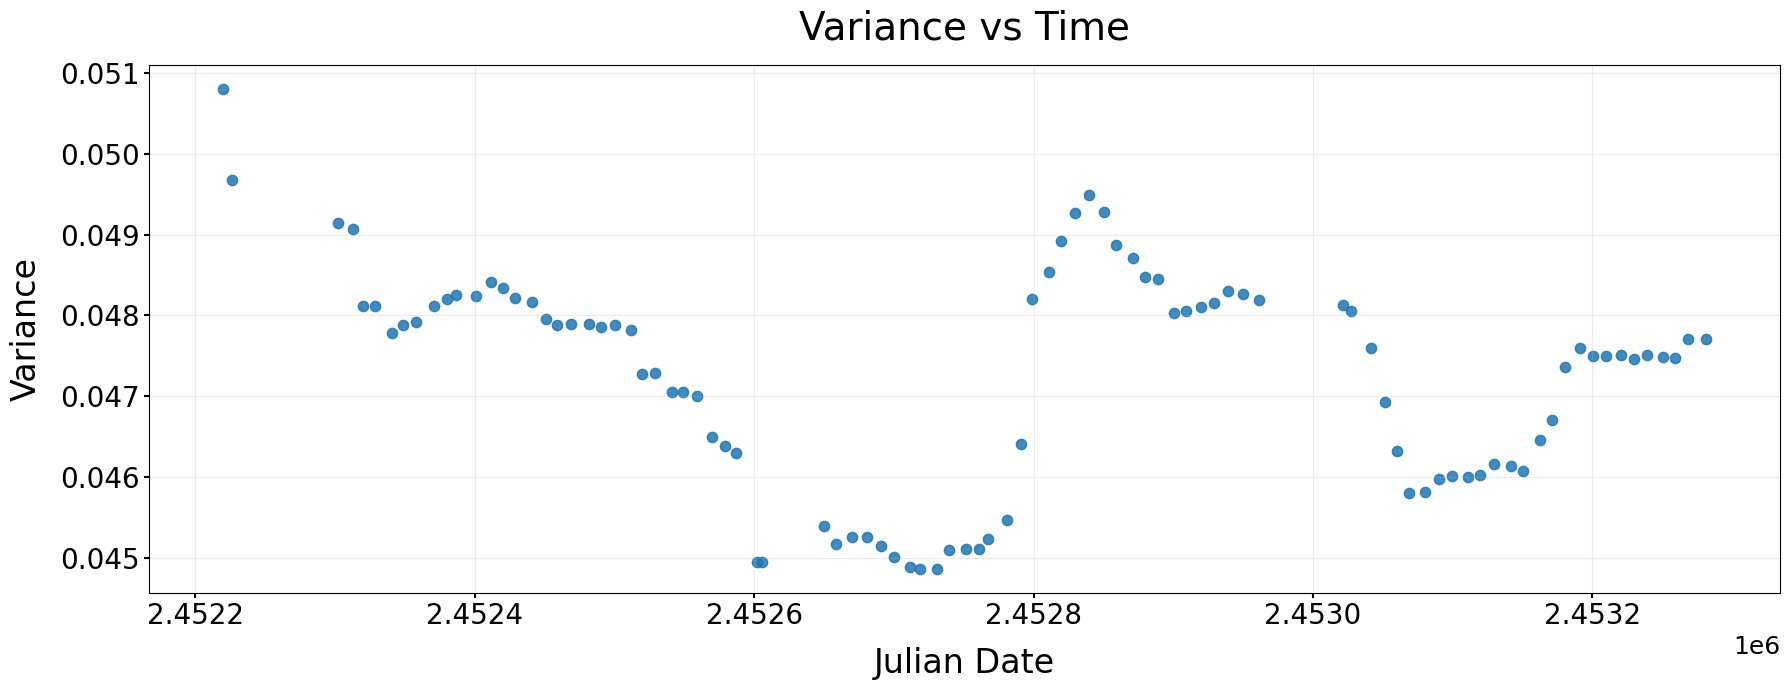

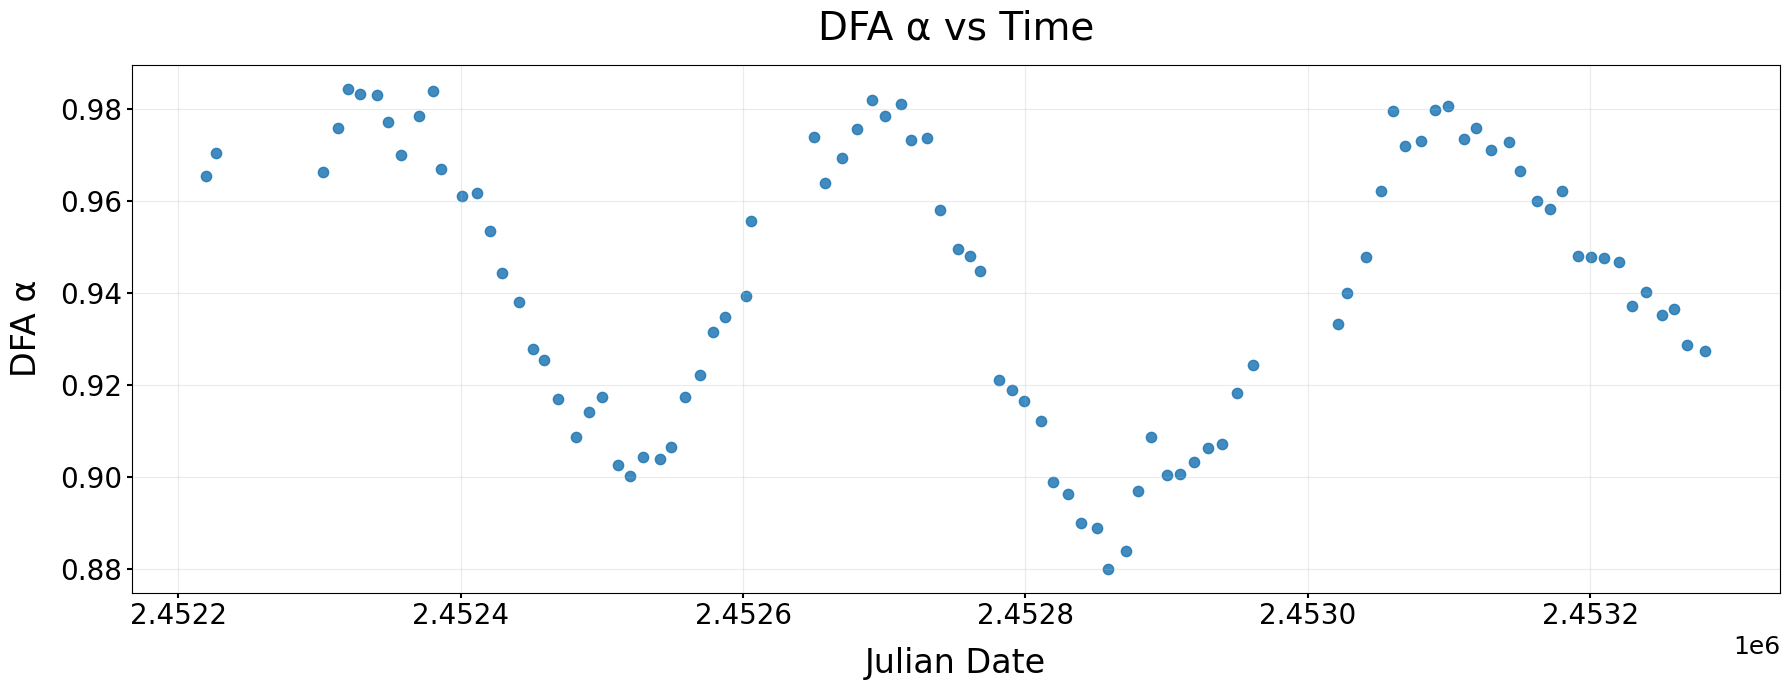

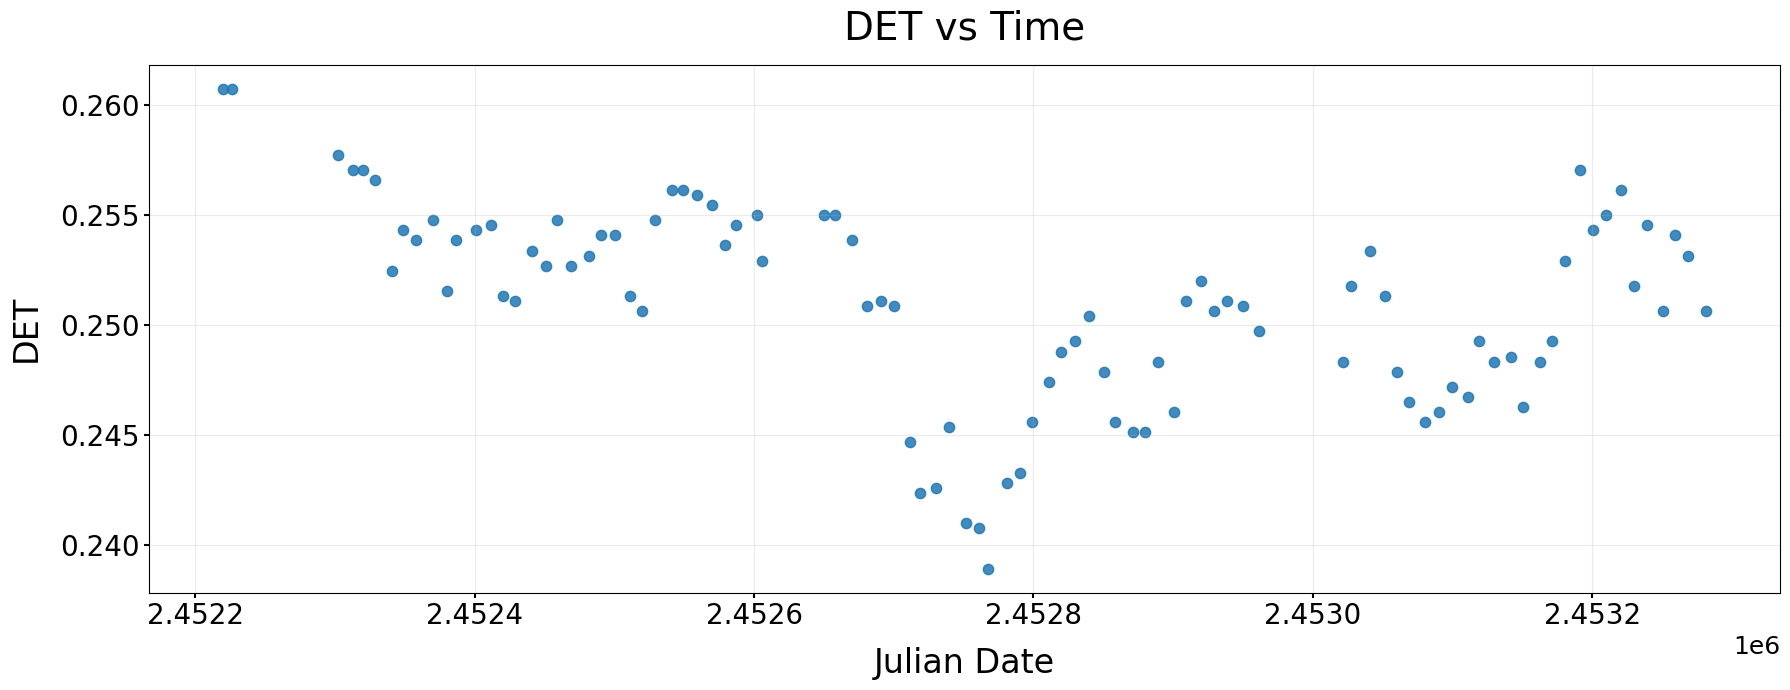

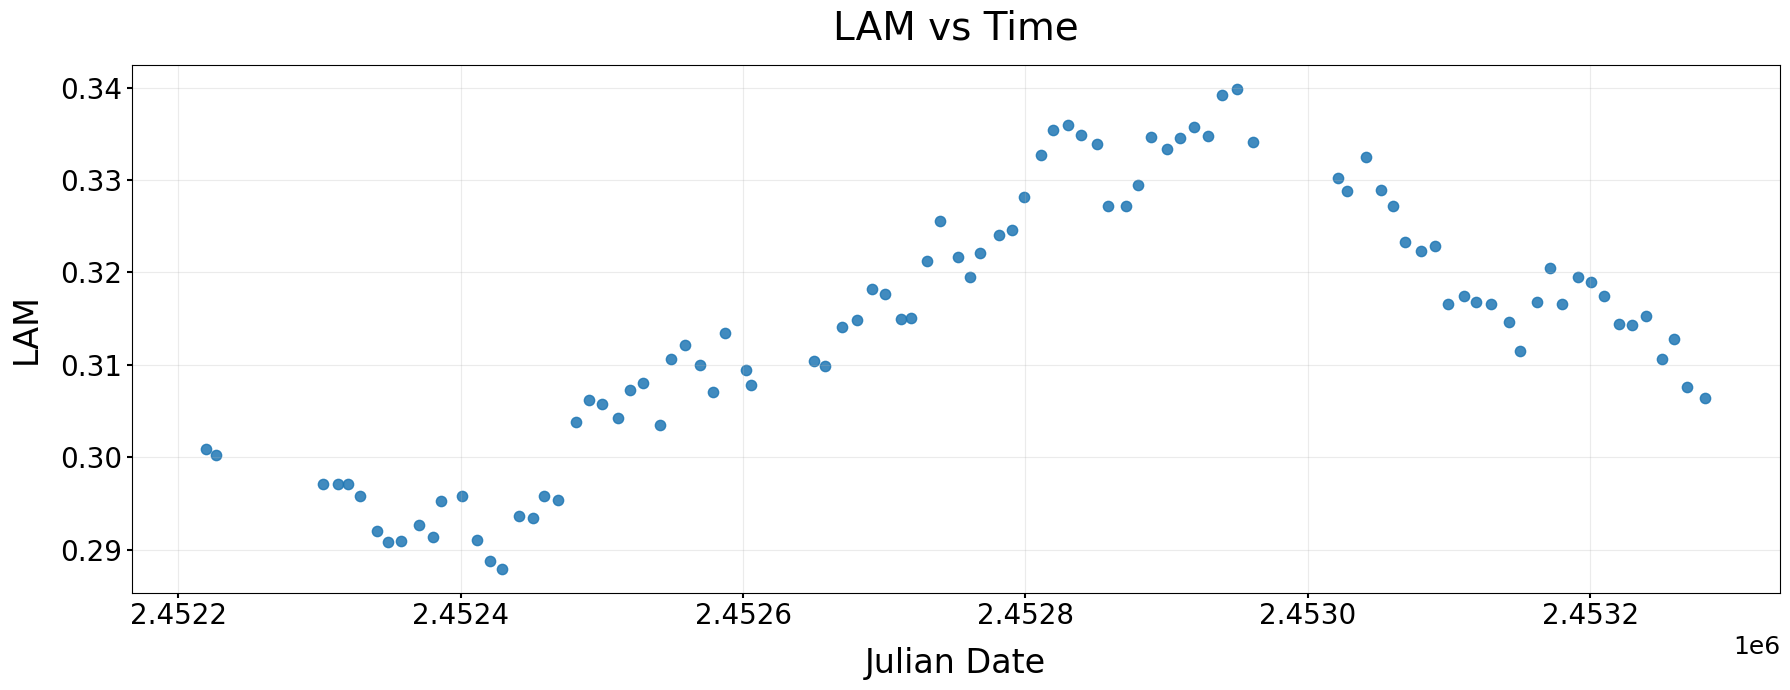


First JD : 2452220.0411055554
Last JD  : 2453281.2056744187


In [19]:
mag_gy=detrend(jd_fourth,mag_fourth,3)
ews(jd_fourth,mag_gy,300,"Fourth Outburst RS Oph")

Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...


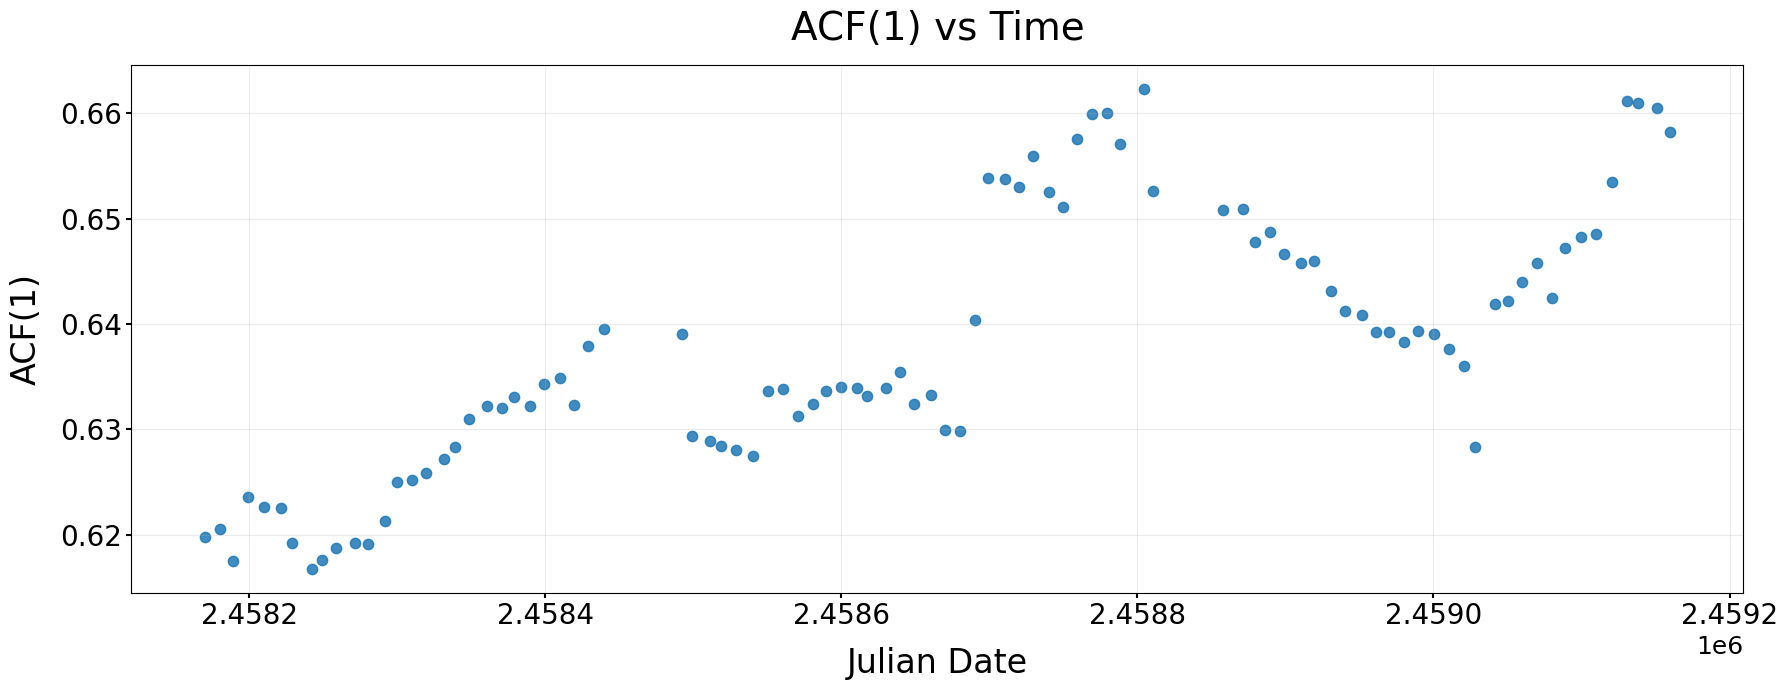

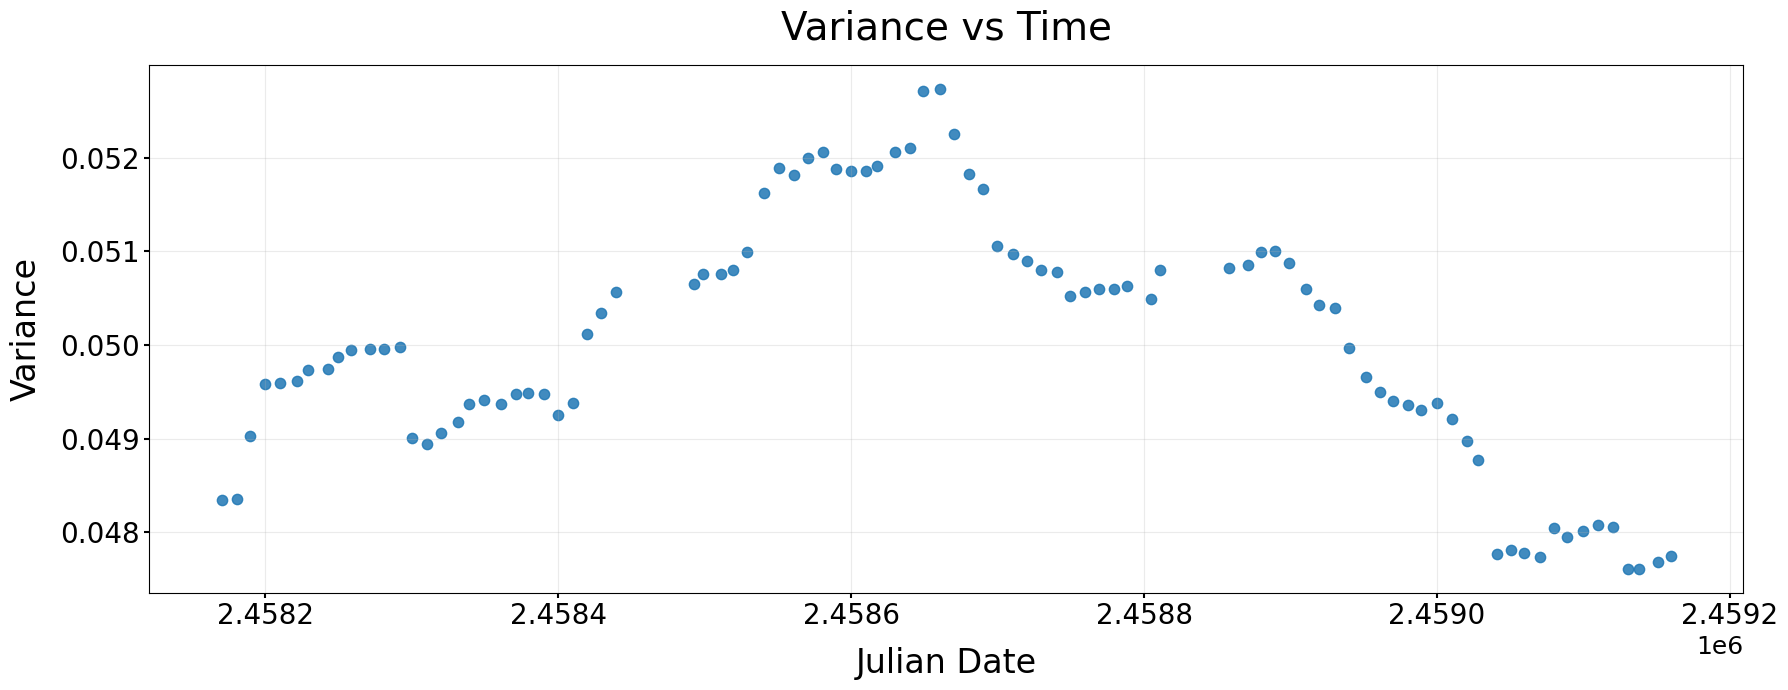

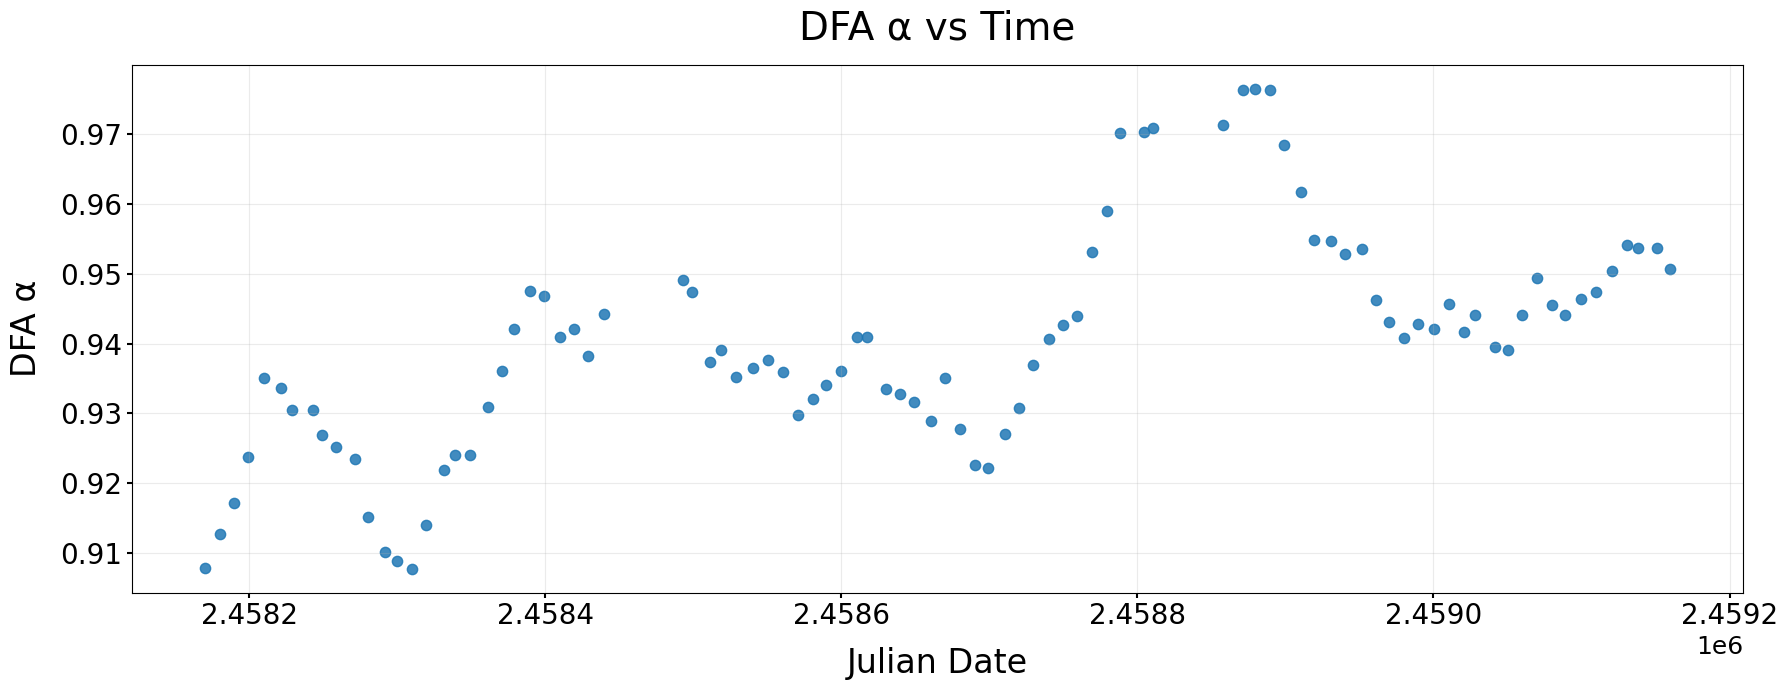

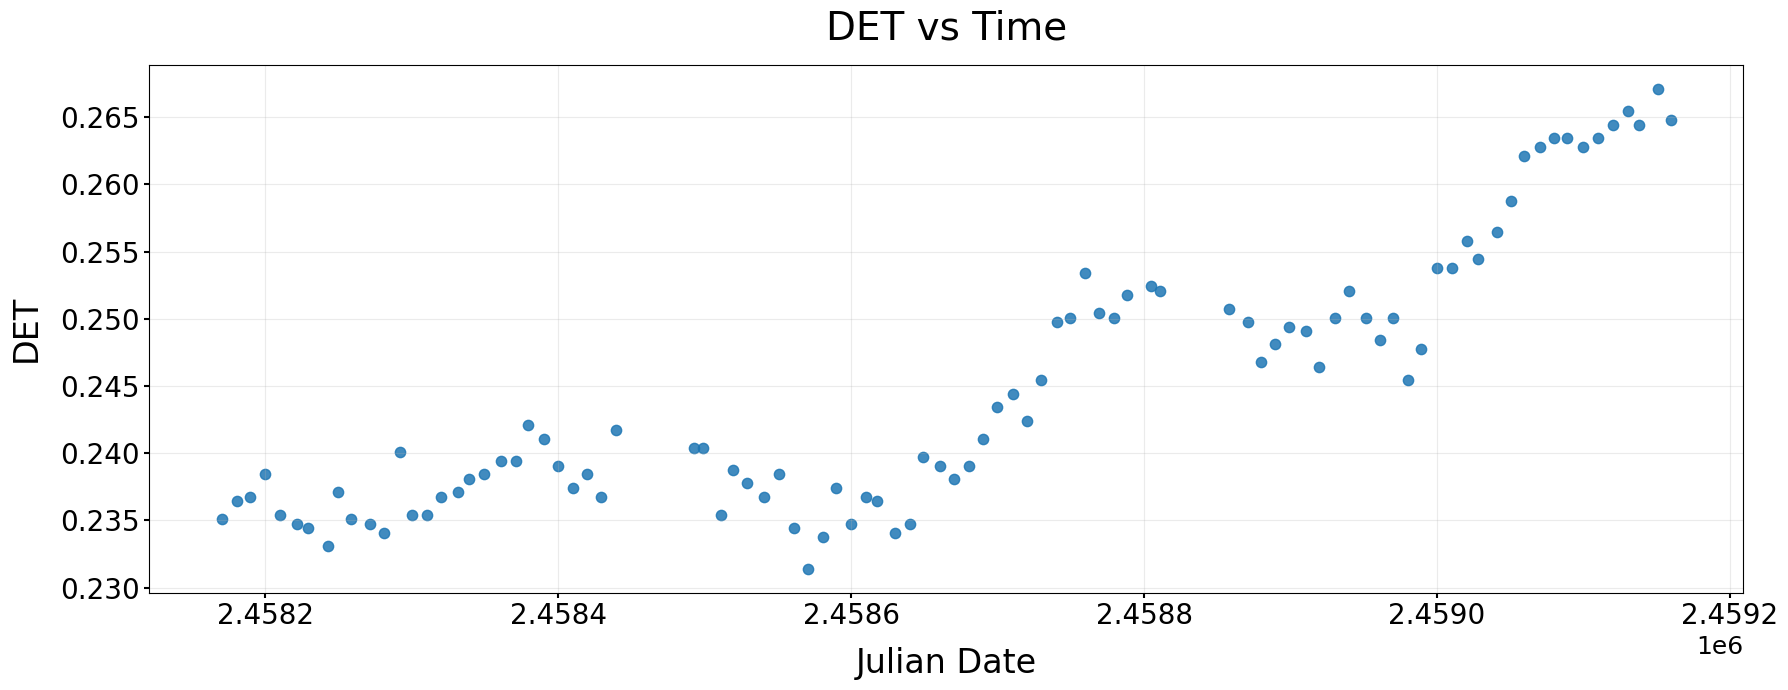

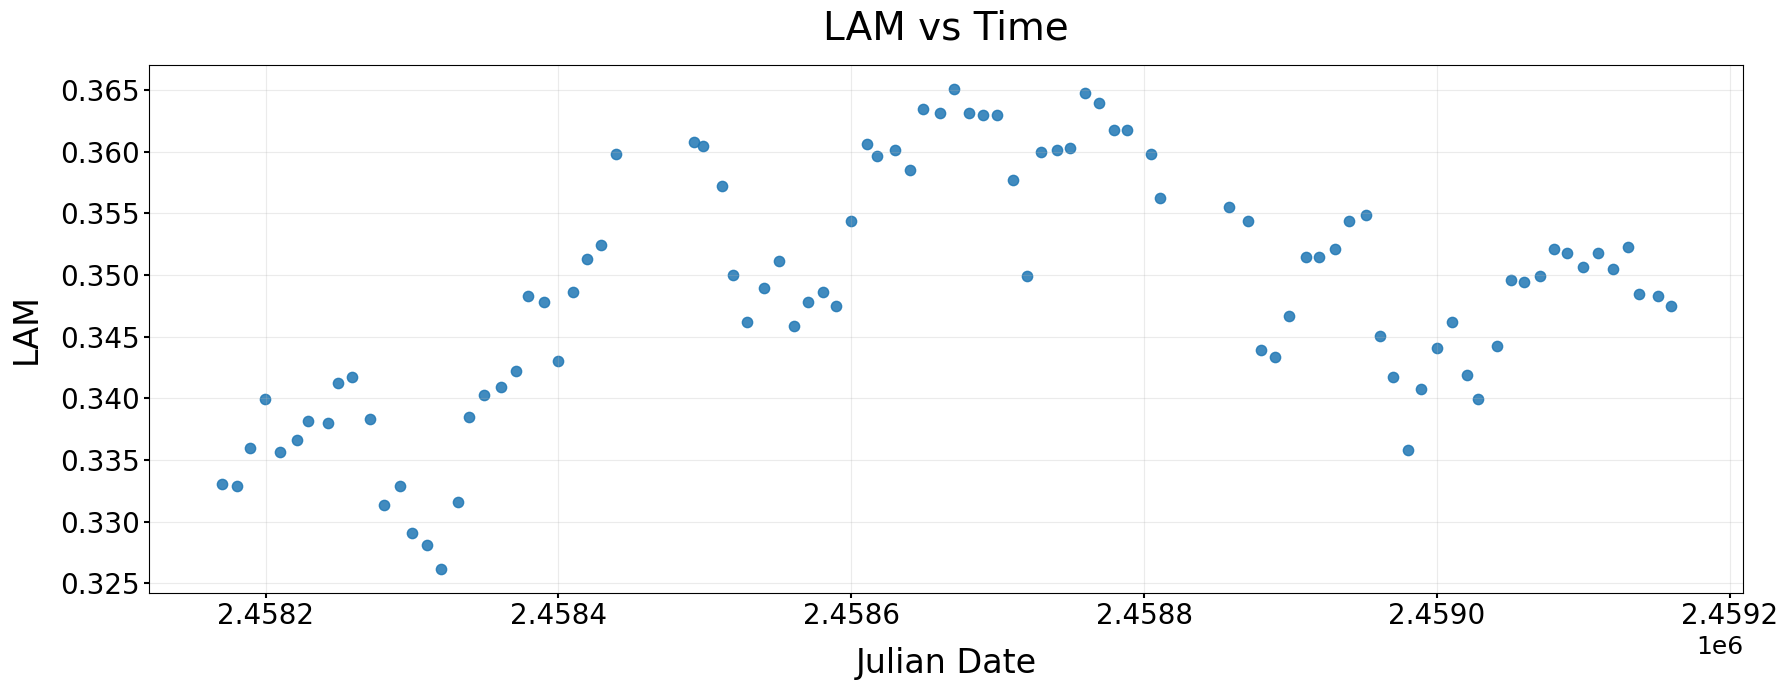


First JD : 2458170.0373142855
Last JD  : 2459159.8342469996


In [20]:
mag_gy=detrend(jd_fifth,mag_fifth,3)
ews(jd_fifth,mag_gy,250,"Fifth Outburst RS Oph")

In [21]:
end = time.time()

print(f"Total runtime of the program is {end - start} seconds")

Total runtime of the program is 706.4377830028534 seconds
